# Exploratory Data Analysis (EDA): Predicción de Churn en una Telco

Este notebook contiene la primera fase del Challenge . El objetivo es explorar el comportamiento de los clientes durante un periodo de 3 meses para identificar patrones que preceden a la fuga (churn) y encontrar insights importantes para establecer una base sólida antes del modelado de los datos.

El análisis se divide en las siguientes partes:

*   Preparación y División Temporal: Segmentación de datos según fechas de negocio.

*   Segmentación por Revenue: Clasificación de clientes según su ARPU.

*   Generación de Variables: Ingeniería de atributos para mejorar la predicción.

*   Análisis de Churn: Comparativa entre clientes que se quedan y los que se van.
*   Estrategia de Limpieza: Decisiones sobre valores nulos y calidad de datos.








## Descripción de variables

### Identificación
- `mobile_number` — Identificador único del cliente
- `last_date_of_month` — Fecha del período (Jun / Jul / Ago 2014)

### Revenue
- `arpu` — Ingreso promedio por usuario ese mes (Average Revenue Per User)
- `arpu_2g` — ARPU generado por uso de datos 2G
- `arpu_3g` — ARPU generado por uso de datos 3G

### Llamadas salientes (OG = Outgoing)
- `onnet_mou` — Minutos dentro de la misma red del operador
- `offnet_mou` — Minutos fuera de la red del operador
- `roam_og_mou` — Minutos salientes en roaming
- `loc_og_mou` — Total minutos locales salientes
  - `loc_og_t2t_mou` — Local, misma red móvil (T to T)
  - `loc_og_t2m_mou` — Local, otra red móvil (T to M)
  - `loc_og_t2f_mou` — Local, línea fija propia del operador (T to Fixed-T)
  - `loc_og_t2c_mou` — Local, call center del operador (T to Call center)
- `std_og_mou` — Total minutos STD salientes (fuera del círculo)
  - `std_og_t2t_mou` — STD, misma red móvil
  - `std_og_t2m_mou` — STD, otra red móvil
  - `std_og_t2f_mou` — STD, línea fija propia del operador
  - `std_og_t2c_mou` — STD, call center (⚠ columna constante, se eliminará)
- `isd_og_mou` — Minutos internacionales salientes (ISD)
- `spl_og_mou` — Minutos de llamadas especiales salientes
- `og_others` — Otros minutos salientes no clasificados
- `total_og_mou` — Total general de minutos salientes

### Llamadas entrantes (IC = Incoming)
- `roam_ic_mou` — Minutos entrantes en roaming
- `loc_ic_mou` — Total minutos locales entrantes
  - `loc_ic_t2t_mou` — Local, misma red móvil
  - `loc_ic_t2m_mou` — Local, otra red móvil
  - `loc_ic_t2f_mou` — Local, línea fija propia del operador
- `std_ic_mou` — Total minutos STD entrantes
  - `std_ic_t2t_mou` — STD, misma red móvil
  - `std_ic_t2m_mou` — STD, otra red móvil
  - `std_ic_t2f_mou` — STD, línea fija propia del operador
  - `std_ic_t2o_mou` — STD, línea fija de OTRO operador (⚠ columna constante)
- `spl_ic_mou` — Minutos especiales entrantes
- `isd_ic_mou` — Minutos internacionales entrantes
- `ic_others` — Otros minutos entrantes
- `total_ic_mou` — Total general de minutos entrantes

### Recargas de voz
- `total_rech_num` — Número de recargas realizadas en el mes
- `total_rech_amt` — Monto total recargado en el mes
- `max_rech_amt` — Monto de la recarga más alta del mes
- `last_day_rch_amt` — Monto recargado el último día del mes
- `date_of_last_rech` — Fecha de la última recarga de voz (4.39% nulos)

### Datos móviles (2G / 3G)
- `vol_2g_mb` — Volumen de datos usados en red 2G (MB)
- `vol_3g_mb` — Volumen de datos usados en red 3G (MB)
- `total_rech_data` — Número de recargas de datos
- `max_rech_data` — Monto máximo de una recarga de datos
- `count_rech_2g` — Veces que recargó paquete 2G en el mes
- `count_rech_3g` — Veces que recargó paquete 3G en el mes
- `av_rech_amt_data` — Monto promedio por recarga de datos
- `date_of_last_rech_data` — Fecha de la última recarga de datos

### Paquetes / Esquemas de servicio
- `night_pck_user` — Nº de veces que activó paquete de horario nocturno
- `fb_user` — Nº de veces que activó paquete de redes sociales (Facebook, etc.)
- `monthly_2g` — Nº de activaciones de paquete mensual 2G
- `sachet_2g` — Nº de activaciones de paquete sachet 2G (validez < 1 mes)
- `monthly_3g` — Nº de activaciones de paquete mensual 3G
- `sachet_3g` — Nº de activaciones de paquete sachet 3G

### Variable objetivo
- `churn` — 1 = el cliente no apareció el mes siguiente, 0 = se quedó

### **0. Carga librerias y Carga de Datos**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import re

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Carga de datos
df  = pd.read_csv('dataset_prueba.csv')
dct = pd.read_csv('data_dict.csv')

print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")
print(f"\nPrimeras filas:")
df.head(3)

Filas    : 299,997
Columnas : 56

Primeras filas:


,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_t2c_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_t2o_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number
0,8/31/2014,213.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.16,4.13,1.15,5.44,0.00,0.00,0.00,0.00,0.00,5.44,0.00,0.00,0.00,2,252,252,8/8/2014,252,8/8/2014,1.00,252.00,0.00,1.00,252.00,5.75,109.61,212.17,212.17,0.00,0,0,1,0,1.00,0,7000842753
1,8/31/2014,268.32,7.68,304.76,0.00,0.00,7.68,291.86,0.00,0.00,299.54,0.00,0.13,0.00,0.00,0.13,0.00,12.76,0.00,312.44,29.23,375.58,3.61,408.43,2.35,12.49,0.00,0.00,14.84,423.28,0.00,0.00,0.00,11,283,65,8/28/2014,30,8/10/2014,2.00,25.00,2.00,0.00,50.00,365.47,0.00,0.00,7.60,0.00,0,2,0,0,1.00,0,7001865778
2,8/31/2014,210.23,37.26,208.36,0.00,0.00,13.58,38.46,15.61,45.76,67.66,22.58,75.53,22.83,0.00,120.94,0.00,96.84,0.00,285.46,67.46,38.89,49.63,155.99,28.69,167.09,43.23,0.00,239.03,395.03,0.00,0.00,0.00,2,116,86,8/14/2014,86,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,0,0,0,0,NaN,0,7001625959


In [3]:
df.groupby('churn')['churn'].value_counts()

,count
churn,
0,293918
1,6079


In [4]:
# Resumen por columna
def metadata_matrix(df):
    return pd.DataFrame({
        'tipo'      : df.dtypes.astype(str),
        'no_nulos'  : df.count(),
        'nulos'     : df.isnull().sum(),
        'pct_nulos' : round(df.isnull().mean() * 100, 2),
        'unicos'    : df.nunique(),
    }).sort_values('pct_nulos', ascending=False)

metadata_matrix(df)

,tipo,no_nulos,nulos,pct_nulos,unicos
max_rech_data,float64,77063,222934,74.31,53
count_rech_2g,float64,77063,222934,74.31,41
count_rech_3g,float64,77063,222934,74.31,34
av_rech_amt_data,float64,77063,222934,74.31,1377
arpu_2g,float64,77063,222934,74.31,14113
arpu_3g,float64,77063,222934,74.31,17455
date_of_last_rech_data,object,77063,222934,74.31,92
total_rech_data,float64,77063,222934,74.31,51
fb_user,float64,77063,222934,74.31,2
night_pck_user,float64,77063,222934,74.31,2


## 1) Análisis de tipo de columna y manejo/imputación de nulos
Esta salida de metadata_matrix nos ayudará en realizar 2 cosas:


1.   Asignar correctamente los tipos de datos a cada columna.
2.   Analizar el grado de nulos que tenemos en cada columna y tomar acción.
3.   Aplicar metodo de imputación correspondiente de ser el caso. Importante: De ser necesario se va a tener que separar train y test antes de hacer esto para evitar data leakge<br>

Comenzaremos primero con asignar los tipos de datos correctamente a cada columna.

In [ ]:
def convertir_tipos(df):
    df = df.copy()

    # 1. Columnas de fecha → datetime
    cols_fecha = [col for col in df.columns if re.match(r'^date', col)]
    for col in cols_fecha:
        df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')
    print(f"  Fechas convertidas: {cols_fecha}")

    # 2. Variables binarias (0/1) que están como float → int
    cols_binarias = ['night_pck_user', 'fb_user']
    for col in cols_binarias:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)
    print(f"  Binarias a int: {cols_binarias}")

    # 3. Variables de conteo discreto pequeño → categóricas
    cols_cat = []
    for col in df.select_dtypes(include=['int64','float64']).columns:
        n = df[col].nunique()
        if n <= 15 and col not in ['churn', 'mobile_number']:
            cols_cat.append(col)
            df[col] = df[col].astype('category')
    print(f"  Convertidas a categóricas ({len(cols_cat)}): {cols_cat}")

    # 4. Columnas constantes → identificar para eliminar después
    cols_constantes = [
        col for col in df.select_dtypes(include=['category','object','int64','float64']).columns
        if df[col].nunique() <= 1
    ]
    print(f"  Columnas constantes (eliminar): {cols_constantes}")

    return df, cols_constantes

In [6]:
df_categorias, cols_constantes = convertir_tipos(df)
df_categorias = df_categorias.drop(columns=cols_constantes)

  Fechas convertidas: ['date_of_last_rech', 'date_of_last_rech_data']
  Binarias a int: ['night_pck_user', 'fb_user']
  Convertidas a categóricas (6): ['std_og_t2c_mou', 'std_ic_t2o_mou', 'night_pck_user', 'monthly_2g', 'monthly_3g', 'fb_user']
  Columnas constantes (eliminar): ['std_og_t2c_mou', 'std_ic_t2o_mou']


In [5]:
df_categorias.head()

,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number
0,8/31/2014,213.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.16,4.13,1.15,5.44,0.00,0.00,0.00,0.00,5.44,0.00,0.00,0.00,2,252,252,2014-08-08,252,2014-08-08,1.00,252.00,0.00,1.00,252.00,5.75,109.61,212.17,212.17,0,0,0,1,0,1,0,7000842753
1,8/31/2014,268.32,7.68,304.76,0.00,0.00,7.68,291.86,0.00,0.00,299.54,0.00,0.13,0.00,0.13,0.00,12.76,0.00,312.44,29.23,375.58,3.61,408.43,2.35,12.49,0.00,14.84,423.28,0.00,0.00,0.00,11,283,65,2014-08-28,30,2014-08-10,2.00,25.00,2.00,0.00,50.00,365.47,0.00,0.00,7.60,0,0,2,0,0,1,0,7001865778
2,8/31/2014,210.23,37.26,208.36,0.00,0.00,13.58,38.46,15.61,45.76,67.66,22.58,75.53,22.83,120.94,0.00,96.84,0.00,285.46,67.46,38.89,49.63,155.99,28.69,167.09,43.23,239.03,395.03,0.00,0.00,0.00,2,116,86,2014-08-14,86,NaT,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,0,0,0,0,0,0,0,7001625959
3,8/31/2014,508.05,310.98,71.68,44.38,39.04,10.61,22.46,4.91,0.00,37.99,289.58,6.53,0.00,296.11,0.00,18.09,0.00,352.21,8.04,20.28,19.84,48.18,0.00,4.94,0.00,4.94,53.13,0.00,0.00,0.00,18,601,50,2014-08-31,50,NaT,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,0,0,0,0,0,0,0,7001204172
4,8/31/2014,238.17,83.89,124.26,0.00,0.00,83.89,124.26,0.00,0.00,208.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,208.16,233.81,104.13,0.00,337.94,0.86,0.00,0.00,0.86,338.81,0.00,0.00,0.00,3,287,110,2014-08-09,110,NaT,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,0,0,0,0,0,0,0,7000142493


Se partirá las variables en grupos de variables para poder manejarlo mejor. <br> Adicionalmente en base al resultado pasado se ha identificado variables que tienen un unico valor y se han retirado del dataset dado que al tener un único valor no permite discriminar para cumplir el objetivo de detectar churn.

In [7]:
# Creación de grupos de variables
# Identificador y fechas
grupo_codigos = [
    'mobile_number',
    'last_date_of_month',
    'date_of_last_rech',       # fecha → no numérica
    'date_of_last_rech_data',  # fecha → no numérica
]

# Revenue_cliente
grupo_revenue = [
    'arpu', 'arpu_2g', 'arpu_3g',
]

# Llamadas salientes
grupo_voz_salida = [
    'onnet_mou', 'offnet_mou', 'roam_og_mou',
    'loc_og_mou', 'loc_og_t2t_mou', 'loc_og_t2m_mou',
    'loc_og_t2f_mou', 'loc_og_t2c_mou',
    'std_og_mou', 'std_og_t2t_mou', 'std_og_t2m_mou',
    'std_og_t2f_mou',
    'isd_og_mou', 'spl_og_mou', 'og_others',
    'total_og_mou',
]

# Llamadas entrantes
grupo_voz_entrada = [
    'roam_ic_mou',
    'loc_ic_mou', 'loc_ic_t2t_mou', 'loc_ic_t2m_mou', 'loc_ic_t2f_mou',
    'std_ic_mou', 'std_ic_t2t_mou', 'std_ic_t2m_mou',
    'std_ic_t2f_mou',
    'spl_ic_mou', 'isd_ic_mou', 'ic_others',
    'total_ic_mou',
]

# Recargas de voz
grupo_recargas_voz = [
    'total_rech_num', 'total_rech_amt', 'max_rech_amt',
    'last_day_rch_amt',
]

# Datos móviles 2G/3G
grupo_datos_mobiles = [
    'vol_2g_mb', 'vol_3g_mb',
    'total_rech_data', 'max_rech_data',
    'count_rech_2g', 'count_rech_3g',
    'av_rech_amt_data',
]

# Paquetes / esquemas de servicio
grupo_paquetes_uso = [
    'night_pck_user', 'fb_user',
    'monthly_2g', 'sachet_2g',
    'monthly_3g', 'sachet_3g',
]

# Variable objetivo
target = 'churn'

# ── Resumen ────────────────────────────────────────────────────────────────
grupos = {
    'Identificador / fechas' : grupo_codigos,
    'Revenue cliente)'          : grupo_revenue,
    'Voz saliente'       : grupo_voz_salida,
    'Voz entrante'       : grupo_voz_entrada,
    'Recargas de voz'         : grupo_recargas_voz,
    'Datos móviles'     : grupo_datos_mobiles,
    'Uso de Paquetes'     : grupo_paquetes_uso,
}

print(f"{'Grupo':<28} {'N° cols':>7}  {'Nulos aprox':>12}")
print("─" * 52)
for nombre, cols in grupos.items():
    nulos = df_categorias[cols].isnull().mean().mean() * 100 if cols else 0
    print(f"{nombre:<28} {len(cols):>7}  {nulos:>11.1f}%")

Grupo                        N° cols   Nulos aprox
────────────────────────────────────────────────────
Identificador / fechas             4         19.3%
Revenue cliente)                   3         49.5%
Voz saliente                      16          4.1%
Voz entrante                      13          4.1%
Recargas de voz                    4          0.0%
Datos móviles                      7         53.1%
Uso de Paquetes                    6          0.0%


In [7]:
df_categorias['mobile_number'].value_counts().sum()

np.int64(299997)

#### 1.1) Análisis de la columna "ladt_date_of_month" y sus nulos

In [9]:
# Analizamos la distribución en el churn
print(df_categorias['last_date_of_month'].isna().sum())
df_fecha_nula = df_categorias[df_categorias['last_date_of_month'].isna()]
print("\nDistribución de Churn en registros sin fecha:")
print(df_fecha_nula['churn'].value_counts(dropna=False))

1701

Distribución de Churn en registros sin fecha:
churn
1    1646
0      55
Name: count, dtype: int64


In [10]:
# Evaluamos que % de los clientes con la fecha en null tienen 2 fechas de modo que se podría llenar la 3era con la fecha faltante
cliente_churn_un = df_fecha_nula['mobile_number'][(df_fecha_nula['churn'] == 1)].unique()
conteo = df_categorias[df_categorias['mobile_number'].isin(cliente_churn_un)]\
           .groupby('mobile_number')['last_date_of_month'].count()

conteo_2 = conteo[conteo == 2]
print(round((len(conteo_2) / len(df_fecha_nula['mobile_number'].unique())) * 100,2))

49.27


In [11]:
# Analizamos como estan compuesta sus otras columnas para corroborar si vale la pena inputarlas
null_density_nula = df_fecha_nula.isnull().mean() * 100
print("\nTop columnas con más vacíos en este grupo (%):")
print(null_density_nula.sort_values(ascending=False).head(30))


Top columnas con más vacíos en este grupo (%):
last_date_of_month   100.00
onnet_mou            100.00
roam_ic_mou          100.00
offnet_mou           100.00
roam_og_mou          100.00
loc_og_t2t_mou       100.00
std_og_mou           100.00
loc_og_t2m_mou       100.00
loc_og_t2f_mou       100.00
loc_og_t2c_mou       100.00
loc_og_mou           100.00
std_og_t2t_mou       100.00
std_og_t2m_mou       100.00
std_og_t2f_mou       100.00
loc_ic_t2t_mou       100.00
isd_og_mou           100.00
spl_og_mou           100.00
og_others            100.00
loc_ic_t2f_mou       100.00
loc_ic_t2m_mou       100.00
std_ic_t2t_mou       100.00
loc_ic_mou           100.00
arpu_3g              100.00
total_rech_data      100.00
std_ic_t2m_mou       100.00
std_ic_t2f_mou       100.00
std_ic_mou           100.00
spl_ic_mou           100.00
isd_ic_mou           100.00
ic_others            100.00
dtype: float64


In [11]:
df_categorias[['last_date_of_month', 'churn']][df_categorias['mobile_number'] == 7000634841].head()

,last_date_of_month,churn
98479,NaN,1
198478,NaN,1
298477,6/30/2014,1


**Decisión sobre registros con last_date_of_month en null** <br>
A continuación se mencionarán los hallazgos para justificar la decisión final sobre estos nulos en el campo last_date_of_month

*   Son 1701 registro sin fecha -> 1646 tienen churn=1 y 55 tienen churn=0.
*   Del grupo con churn = 1, el 49% tiene 2 fechas conocidas y la fecha faltante pordría inferirse en base a esto. El 51% no es recuperable ni es posible inferirlo dado que faltan 2 fechas o más.
*   De estas filas con null en la fecha, casi el 100% de las columnas de comportamiento no tienen ningun valor.

**Conclusión**
Aunque para este 49% podría ser rescatable el asignarle un valor a la fecha faltante, esta estaría practicamente vacía de información lo cual generaría ruido en el analisis y el modelo. Además representa un 0.57% del dataset.<br>
Se decide excluir estos registros del análisis y no tratarlos.



In [12]:
df_nona_date = df_categorias[~df_categorias['last_date_of_month'].isna()]
df_nona_date['last_date_of_month'].unique()

array(['8/31/2014', '7/31/2014', '6/30/2014'], dtype=object)

In [141]:
# Split por fecha para empezar la imputación
TRAIN_DATES = ['6/30/2014', '7/31/2014']
TEST_DATE   = '8/31/2014'

df_train = df_nona_date[df_nona_date['last_date_of_month'].isin(TRAIN_DATES)].copy()
df_test  = df_nona_date[df_nona_date['last_date_of_month'] == TEST_DATE].copy()

In [37]:
metadata_matrix(df_train)

,tipo,no_nulos,nulos,pct_nulos,unicos
count_rech_3g,float64,50724,148673,74.56,30
av_rech_amt_data,float64,50724,148673,74.56,1171
arpu_2g,float64,50724,148673,74.56,10976
arpu_3g,float64,50724,148673,74.56,12711
date_of_last_rech_data,datetime64[ns],50724,148673,74.56,61
total_rech_data,float64,50724,148673,74.56,47
max_rech_data,float64,50724,148673,74.56,50
count_rech_2g,float64,50724,148673,74.56,39
loc_og_t2f_mou,float64,192202,7195,3.61,4972
loc_og_t2c_mou,float64,192202,7195,3.61,2974


#### 1.2) Imputación de datos

In [ ]:
# Imputación
# GRUPO 1: Variables de datos 2G/3G (74.56% nulos)
cols_grupo_datos = [
    'count_rech_3g', 'av_rech_amt_data', 'arpu_2g', 'arpu_3g',
    'total_rech_data', 'max_rech_data', 'count_rech_2g',
]

for col in cols_grupo_datos:
    df_train[col] = df_train[col].fillna(0)
    df_test[col]  = df_test[col].fillna(0)

print(f"Grupo 1 imputado: {len(cols_grupo_datos)} columnas → fillna(0)")

Grupo 1 imputado: 7 columnas → fillna(0)


In [ ]:

# GRUPO 2: Variables de minutos (3.61% nulos)
# Si donde hay nulos en _mou el total_og_mou y total_ic_mou son 0

cols_voz_con_nulos = [
    col for col in df_train.columns
    if df_train[col].isnull().mean() > 0.03
    and df_train[col].isnull().mean() < 0.05
    and col not in cols_grupo_datos
    and col not in ['date_of_last_rech', 'date_of_last_rech_data']
]

# Filas donde TODAS las columnas de voz son nulas simultáneamente
mask_todos_nulos = df_train[cols_voz_con_nulos].isnull().all(axis=1)

og_vals = df_train.loc[mask_todos_nulos, 'total_og_mou'].unique()
ic_vals = df_train.loc[mask_todos_nulos, 'total_ic_mou'].unique()

print(f"\nGrupo 2 — verificación previa a imputación:")
print(f"  Columnas con ~3.61% nulos: {len(cols_voz_con_nulos)}")
print(f"  Filas donde todas son nulas simultáneamente: {mask_todos_nulos.sum():,}")
print(f"  total_og_mou en esas filas: {og_vals}")
print(f"  total_ic_mou en esas filas: {ic_vals}")
print(f"  → {'✓ Confirmado: nulo = inactivo → fillna(0)' if list(og_vals) == [0.0] and list(ic_vals) == [0.0] else '⚠ Revisar: hay valores distintos de 0'}")


Grupo 2 — verificación previa a imputación:
  Columnas con ~3.61% nulos: 27
  Filas donde todas son nulas simultáneamente: 7,195
  total_og_mou en esas filas: [0.]
  total_ic_mou en esas filas: [0.]
  → ✓ Confirmado: nulo = inactivo → fillna(0)


In [ ]:
# Imputar Grupo 2 solo si la verificación confirmó que son ceros
for col in cols_voz_con_nulos:
    df_train[col] = df_train[col].fillna(0)
    df_test[col]  = df_test[col].fillna(0)

print(f"Grupo 2 imputado: {len(cols_voz_con_nulos)} columnas → fillna(0)")

# GRUPO 3: Fechas de recarga (1.39% nulos)
# Verificación: donde date_of_last_rech es NaT, entonces el total_rech_amt (monto de recarga) = 0 ?
mask_sin_fecha = df_train['date_of_last_rech'].isnull()

rech_amt_vals = df_train.loc[mask_sin_fecha, 'total_rech_amt'].unique()
rech_num_vals = df_train.loc[mask_sin_fecha, 'total_rech_num'].unique()

print(f"\nGrupo 3 — verificación date_of_last_rech:")
print(f"  Filas con NaT en date_of_last_rech: {mask_sin_fecha.sum():,}")
print(f"  total_rech_amt en esas filas: {rech_amt_vals}")
print(f"  total_rech_num en esas filas: {rech_num_vals}")
print(f"  → Nulo = cliente que no recargó ese mes → se deja como NaT")
print(f"  → Ya capturado en recency_dias como 31 días (inactividad total)")

# date_of_last_rech_data: mismo criterio, se deja como NaT
print(f"\n  date_of_last_rech_data → también se deja como NaT")
print(f"  (nulo = cliente sin recargas de datos ese mes)")

Grupo 2 imputado: 27 columnas → fillna(0)

Grupo 3 — verificación date_of_last_rech:
  Filas con NaT en date_of_last_rech: 2,773
  total_rech_amt en esas filas: [0]
  total_rech_num en esas filas: [0]
  → Nulo = cliente que no recargó ese mes → se deja como NaT
  → Ya capturado en recency_dias como 31 días (inactividad total)

  date_of_last_rech_data → también se deja como NaT
  (nulo = cliente sin recargas de datos ese mes)


In [ ]:
# Verificación final 
nulos_train = df_train.isnull().sum()
nulos_train = nulos_train[nulos_train > 0].sort_values(ascending=False)

print("\nNulos restantes en df_train:")
print(f"{'Columna':<30} {'Nulos':>8}  {'%':>8}")
print("─" * 50)
for col, n in nulos_train.items():
    pct = n / len(df_train) * 100
    print(f"{col:<30} {n:>8,}  {pct:>7.2f}%")

print(f"\nTotal columnas con nulos: {len(nulos_train)}")
print(f"Esperado: solo date_of_last_rech y date_of_last_rech_data")


Nulos restantes en df_train:
Columna                           Nulos         %
──────────────────────────────────────────────────
date_of_last_rech_data          148,673    74.56%
date_of_last_rech                 2,773     1.39%

Total columnas con nulos: 2
Esperado: solo date_of_last_rech y date_of_last_rech_data


Se identificaron 3 grupos de nulos con tratamientos distintos:

**Grupo 1 — Variables de datos 2G/3G (74.56% nulos)**
Columnas: arpu_2g, arpu_3g, count_rech_2g, count_rech_3g,
total_rech_data, max_rech_data, av_rech_amt_data.
Decisión: fillna(0).
Justificación: el nulo no es un error sino información.
Un cliente sin registro en estas columnas simplemente
no usó datos móviles ese mes.

**Grupo 2 — Variables de voz, roaming y STD (3.61% nulos)**
27 columnas del tipo _mou (minutos de uso).
Verificación previa: se confirmó que las 7.195 filas
con nulos en estas columnas tienen total_og_mou = 0
y total_ic_mou = 0 simultáneamente.
Decisión: fillna(0).
Justificación: nulo = cliente inactivo en voz ese mes,
no un dato faltante.

**Grupo 3 — Fechas de recarga (1.39% nulos)**
Columnas: date_of_last_rech, date_of_last_rech_data.
Verificación: donde hay NaT, total_rech_amt = 0
y total_rech_num = 0.
Decisión: se dejan como NaT.
Justificación: nulo = cliente que no recargó ese mes.
Ya capturado en la variable recency_dias (NaT → 31 días).

**Resultado**
- Columnas con nulos antes: 37
- Columnas con nulos después: 2 (solo fechas, por diseño)
- Ninguna imputación estadística fue necesaria
- Todas las decisiones se basan en la semántica propio de entendimiento del negocio y sus variables

In [146]:
metadata_matrix(df_train)

,tipo,no_nulos,nulos,pct_nulos,unicos
date_of_last_rech_data,datetime64[ns],50724,148673,74.56,61
date_of_last_rech,datetime64[ns],196624,2773,1.39,61
onnet_mou,float64,199397,0,0.00,34787
offnet_mou,float64,199397,0,0.00,42257
last_date_of_month,object,199397,0,0.00,2
arpu,float64,199397,0,0.00,157624
loc_og_t2t_mou,float64,199397,0,0.00,18210
loc_og_t2m_mou,float64,199397,0,0.00,27336
loc_og_t2f_mou,float64,199397,0,0.00,4972
loc_og_t2c_mou,float64,199397,0,0.00,2974


## 2) Segmentación de clientes usando la variable ARPU

In [147]:
def cluster_rfm_comportamiento_grafico(df):
    print("Calculando matriz RFM + Engagement...")
    df_rfm = df.copy()

    # 1. Crear variables de USO (Engagement)
    df_rfm['uso_total_datos_mb'] = df_rfm['vol_2g_mb'] + df_rfm['vol_3g_mb']
    df_rfm['uso_total_voz_mou'] = df_rfm['total_og_mou'] + df_rfm['total_ic_mou']

    # 2. Crear variable R (Recency)
    #df_rfm['last_date_of_month'] = pd.to_datetime(df_rfm['last_date_of_month'])
    df_rfm['date_of_last_rech'] = pd.to_datetime(df_rfm['date_of_last_rech'])

    # Días desde la última recarga. Si es NaN (no recargó), asumimos inactividad total (31 días)
    df_rfm['recency_dias'] = (pd.to_datetime(df_rfm['last_date_of_month']) - df_rfm['date_of_last_rech']).dt.days
    df_rfm['recency_dias'] = df_rfm['recency_dias'].fillna(31)

    # 3. Features Híbridos
    features = ['recency_dias', 'total_rech_num', 'arpu', 'uso_total_voz_mou', 'uso_total_datos_mb']
    X = df_rfm[features].fillna(0)

    # 4. Estandarizar y Clusterizar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df_rfm['Cluster_RFM'] = kmeans.fit_predict(X_scaled)

    # 5. PCA para visualización 2D general
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df_rfm['PCA_1'] = X_pca[:, 0]
    df_rfm['PCA_2'] = X_pca[:, 1]

    # --- SECCIÓN DE GRÁFICOS ---
    fig, axes = plt.subplots(figsize=(10, 7))
    muestra = df_rfm.sample(n=min(10000, len(df_rfm)), random_state=42) # Muestra para no saturar

    # Gráfico 2: Visión Matemática (PCA Multidimensional)
    sns.scatterplot(x='PCA_1', y='PCA_2', hue='Cluster_RFM',
                    palette='tab10', data=muestra, alpha=0.6, s=50, edgecolor=None, legend=False)
    var_expl = pca.explained_variance_ratio_
    plt.title(f'Visión Técnica: Proyección PCA 2D\n(Varianza retenida: {sum(var_expl)*100:.1f}%)', fontsize=14)
    plt.xlabel(f'Componente 1 ({var_expl[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'Componente 2 ({var_expl[1]*100:.1f}%)', fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- PERFILADO ---
    perfil = df_rfm.groupby('Cluster_RFM')[features].mean().round(1)
    perfil['Cantidad'] = df_rfm['Cluster_RFM'].value_counts()
    perfil['% Churn'] = (df_rfm.groupby('Cluster_RFM')['churn'].mean() * 100).round(2)

    print("\n--- Perfiles de Clusters Híbridos (RFM + Engagement) ---")
    display(perfil)
    df_rfm = df_rfm.drop(columns=['PCA_1', 'PCA_2'])
    return df_rfm, scaler, kmeans

Calculando matriz RFM + Engagement...


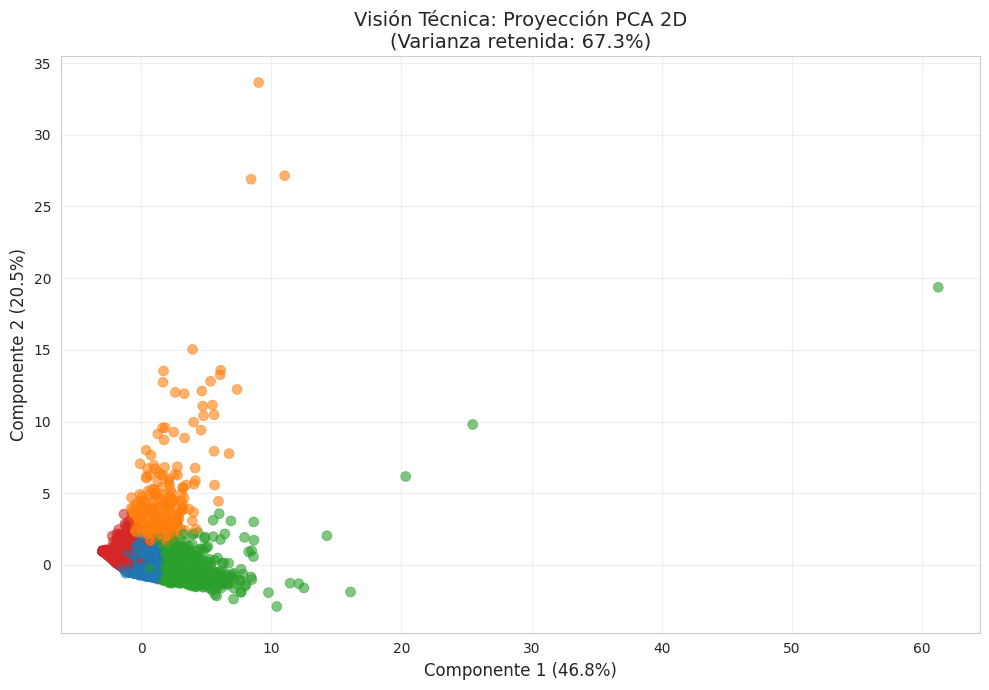


--- Perfiles de Clusters Híbridos (RFM + Engagement) ---


,recency_dias,total_rech_num,arpu,uso_total_voz_mou,uso_total_datos_mb,Cantidad,% Churn
Cluster_RFM,,,,,,,
0,3.20,7.10,218.50,389.40,100.40,119242,0.60
1,4.40,10.10,672.80,512.30,2585.60,5932,0.35
2,1.90,18.10,770.30,1583.30,157.10,26358,0.47
3,15.80,3.00,121.20,222.10,81.50,47865,3.53


In [148]:
df_train_procesado, scaler_rfm, kmeans_rfm = cluster_rfm_comportamiento_grafico(df_train)

In [149]:
df_train_procesado.head(3)

,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number,uso_total_datos_mb,uso_total_voz_mou,recency_dias,Cluster_RFM
99999,7/31/2014,214.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,252,252,2014-07-16,252,2014-07-16,1.00,252.00,0.00,1.00,252.00,1.32,150.76,212.17,212.17,0,0,0,1,0,1,0,7000842753,152.08,0.00,15.00,3
100000,7/31/2014,355.07,78.68,99.84,0.00,0.00,74.56,75.94,0.00,2.91,150.51,4.11,0.46,0.00,4.58,0.00,23.43,0.00,178.53,29.91,65.38,8.93,104.23,0.00,0.00,0.00,0.00,104.23,0.00,0.00,0.00,9,384,154,2014-07-31,23,2014-07-25,1.00,154.00,1.00,0.00,154.00,108.07,0.00,0.00,28.61,0,1,0,0,0,1,0,7001865778,108.07,282.76,0.00,0
100001,7/31/2014,189.06,55.24,220.59,0.00,0.00,28.74,16.86,21.79,135.54,67.41,26.49,67.41,14.76,108.68,0.00,236.84,0.00,412.94,71.11,15.44,122.29,208.86,71.29,177.01,58.34,306.66,519.53,0.00,0.85,3.14,4,315,200,2014-07-24,200,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7001625959,0.00,932.47,7.00,0


Inicialmente, se planteó utilizar un análisis bidimensional estático (Scatterplot) cruzando ARPU y Uso para generar segmentos manuales. Sin embargo, para obtener una clasificación más robusta y orgánica, se decidió escalar la estrategia a un modelo no supervisado (Clustering K-Means). El objetivo era crear segmentos que no solo consideren el retorno financiero (ARPU), sino también el 'Engagement' multidimensional del cliente (Minutos de voz y Volumen de datos).

Finalmente, para maximizar el poder predictivo hacia el Churn, se evolucionó la matriz integrando la lógica RFM (Recency, Frequency, Monetary). Al añadir la 'Recencia' (días desde la última recarga), el algoritmo logró encontrar patrones de comportamiento temporal mucho más precisos. Los resultados de esta segmentación híbrida se detallan a continuación:



*   Cluster 0 - "Masivo": Representa el grueso de la compañía (~119k clientes). Tienen un consumo regular (ARPU de 218, 389 min, 100 MB) y recargan semanalmente (cada ~3 días). Son la base estable (Churn bajo del 0.60%).

*   Cluster 1 - "Premiun": Es un nicho exclusivo (~6k clientes). Lo que los define es el consumo brutal de datos (2,585 MB, que es 25 veces más que el Masivo). Tienen el Churn más bajo de todos (0.35%).

*   Cluster 2 - "Power": Representan a los usuarios comerciales o de negocios (~26k clientes). Tienen la mejor Recencia (recargan casi cada 2 días) y hablan muchísimo (1,583 min). Son altamente rentables (ARPU 770) y leales.

*   Cluster 3 - "Abandono": Son ~48k clientes que casi no usan la red (222 min, 81 MB), recargan poco (3 veces/mes), pero lo más crítico es que llevan casi 16 días sin recargar. Esta inactividad dispara su Churn al 3.53%.

La proyección 2D retiene el 67.3% de la varianza total. Esta proyección visual es orientativa dado que los cluster estan definiidos en las 5 dimenciones originales.

## 3) Generación de variables / Feature engineering

In [150]:
def aplicar_clusters_a_test(df_test, scaler_entrenado, kmeans_entrenado):
    print("Aplicando lógica de segmentación a la data de Test...")
    df_rfm = df_test.copy()

    # 1. Recrear las mismas variables de USO
    df_rfm['uso_total_datos_mb'] = df_rfm['vol_2g_mb'] + df_rfm['vol_3g_mb']
    df_rfm['uso_total_voz_mou'] = df_rfm['total_og_mou'] + df_rfm['total_ic_mou']

    # 2. Recrear variable de Recencia
    #df_rfm['last_date_of_month'] = pd.to_datetime(df_rfm['last_date_of_month'])
    df_rfm['date_of_last_rech'] = pd.to_datetime(df_rfm['date_of_last_rech'])

    df_rfm['recency_dias'] = (pd.to_datetime(df_rfm['last_date_of_month']) - df_rfm['date_of_last_rech']).dt.days
    df_rfm['recency_dias'] = df_rfm['recency_dias'].fillna(31)

    # 3. Seleccionar las características EXACTAMENTE en el mismo orden
    features = ['recency_dias', 'total_rech_num', 'arpu', 'uso_total_voz_mou', 'uso_total_datos_mb']
    X_test_nuevo = df_rfm[features].fillna(0)

    # 4. ESCALAR Y PREDECIR (Cero fuga de datos)
    # Usamos .transform() para escalar con las medias del Train
    X_test_scaled = scaler_entrenado.transform(X_test_nuevo)

    # Usamos .predict() para asignar los centroides del Train
    df_rfm['Cluster_RFM'] = kmeans_entrenado.predict(X_test_scaled)

    print("Test procesado exitosamente.")
    return df_rfm

In [151]:
df_test_procesado = aplicar_clusters_a_test(df_test, scaler_rfm, kmeans_rfm)

Aplicando lógica de segmentación a la data de Test...
Test procesado exitosamente.


In [152]:
df_test_procesado.head(2)

,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number,uso_total_datos_mb,uso_total_voz_mou,recency_dias,Cluster_RFM
0,8/31/2014,213.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.16,4.13,1.15,5.44,0.00,0.00,0.00,0.00,5.44,0.00,0.00,0.00,2,252,252,2014-08-08,252,2014-08-08,1.00,252.00,0.00,1.00,252.00,5.75,109.61,212.17,212.17,0,0,0,1,0,1,0,7000842753,115.36,5.44,23.00,3
1,8/31/2014,268.32,7.68,304.76,0.00,0.00,7.68,291.86,0.00,0.00,299.54,0.00,0.13,0.00,0.13,0.00,12.76,0.00,312.44,29.23,375.58,3.61,408.43,2.35,12.49,0.00,14.84,423.28,0.00,0.00,0.00,11,283,65,2014-08-28,30,2014-08-10,2.00,25.00,2.00,0.00,50.00,365.47,0.00,0.00,7.60,0,0,2,0,0,1,0,7001865778,365.47,735.72,3.00,0


In [153]:
print("Distribución de clusters en TEST:")
print(df_test_procesado['Cluster_RFM'].value_counts())
print("\nChurn rate por cluster en TEST:")
print(df_test_procesado.groupby('Cluster_RFM')['churn'].mean() * 100)

Distribución de clusters en TEST:
Cluster_RFM
0    64508
3    18291
2    12939
1     3161
Name: count, dtype: int64

Churn rate por cluster en TEST:
Cluster_RFM
0   0.99
1   0.41
2   0.31
3   6.51
Name: churn, dtype: float64


Para este punto, se aplica el .predict del cluster al dataset de test para asignar el cluster de training y generar las variables creadas previamente las cuales se detallan a continuación:

*   **A. Variables de Volumen Total de Uso**
    Variable Creada: uso_total_datos_mb y uso_total_voz_mou

    Contrucción: Agrupando mediante sumas simples los consumos fragmentados. Para datos, se sumaron vol_2g_mb y vol_3g_mb. Para minutos, se sumaron los minutos salientes (total_og_mou) y entrantes (total_ic_mou).

*   **B. Variable de Inactividad o Recencia**

    Variable Creada: recency_dias

    Contrucción: Calculando la diferencia en días entre el fin de mes (last_date_of_month) y la fecha de la última recarga (date_of_last_rech). A los clientes sin recargas en el mes (NaT) se les imputó un valor de 31 días, el cual se asume inactividad total.

*   **C. Variable de Perfil cliente o Segmento RFM-E**

    Variable Creada: Cluster_RFM (Segmento Estratégico)

    Construcción: Se aplicó un algoritmo no supervisado (K-Means) utilizando la facturación (ARPU), la frecuencia de recargas, el uso total de voz/datos y la recencia. Esto clasificó a cada cliente en uno de 4 perfiles de comportamiento ("Masivo", "Premium", "Power", "Abandono").

**Validación del clustering en Test**

La jerarquía de riesgo se mantiene consistente entre Train y Test:
Cluster 3 (Abandono) sigue siendo el más riesgoso (3.53% → 6.51%).
El incremento general refleja la tendencia creciente del churn
mes a mes.

## 4) Análisis de CHURN

In [ ]:
# Verificación del split
print(f"{'Conjunto':<10} {'Filas':>8}  {'Churn=1':>8}  {'Churn%':>8}")
print("─" * 40)
for nombre, subset in [('TRAIN', df_train_procesado), ('TEST', df_test_procesado), ('TOTAL', df_nona_date)]:
    n   = len(subset)
    c   = subset['churn'].sum()
    pct = subset['churn'].mean() * 100
    print(f"{nombre:<10} {n:>8,}  {c:>8,}  {pct:>7.2f}%")

# Verificar que no se perdieron columnas
print(f"\nTamaño del train : {df_train_procesado.shape[1]}")
print(f"Tamaño del test  : {df_test_procesado.shape[1]}")

Conjunto      Filas   Churn=1    Churn%
────────────────────────────────────────
TRAIN       199,397     2,551     1.28%
TEST         98,899     1,882     1.90%
TOTAL       298,296     4,433     1.49%

Tamaño del train : 58
Tamaño del test  : 58


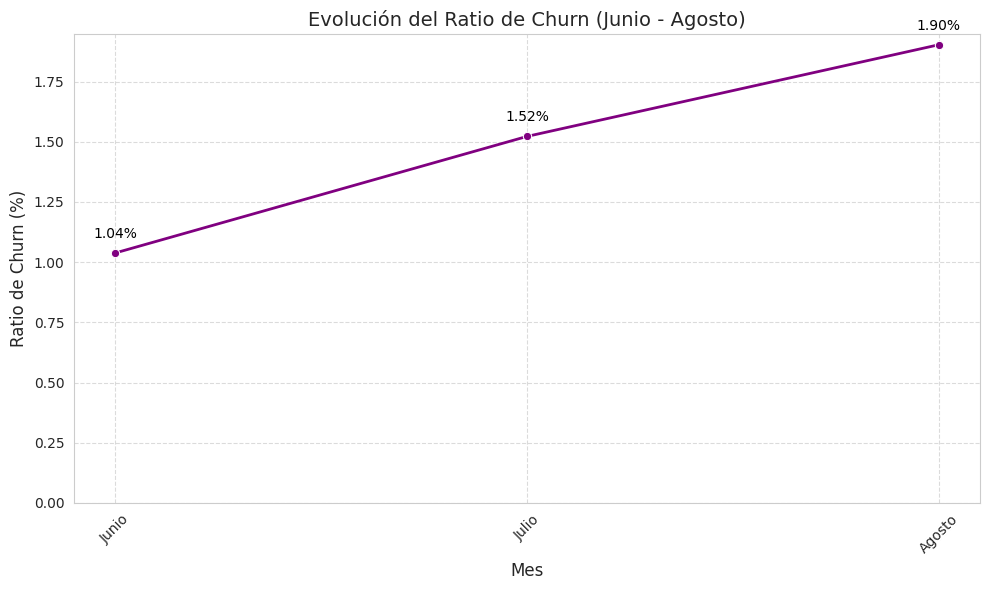

In [155]:
# 1. Filtramos el DataFrame para excluir los NaNs en 'last_date_of_month'
df_filtered = df[df['last_date_of_month'].notna()].copy()

# 2. Convertir la columna 'last_date_of_month' a tipo datetime
df_filtered['last_date_of_month'] = pd.to_datetime(df_filtered['last_date_of_month'])

# 3. Crear una columna para el mes en formato texto y filtrar solo los meses de interés
def formatear_mes(fecha):
    if fecha.month == 6: return '1. Junio'
    if fecha.month == 7: return '2. Julio'
    if fecha.month == 8: return '3. Agosto'
    return None # Excluimos otros meses

df_filtered['mes_eje'] = df_filtered['last_date_of_month'].apply(formatear_mes)

# Eliminar las filas donde 'mes_eje' es None (otros meses)
df_filtered = df_filtered.dropna(subset=['mes_eje'])

# 4. Calcular el ratio de churn por mes
churn_ratio_por_mes = df_filtered.groupby('mes_eje')['churn'].mean() * 100

# Asegurar el orden de los meses
orden_meses = ['1. Junio', '2. Julio', '3. Agosto']
churn_ratio_por_mes = churn_ratio_por_mes.reindex(orden_meses)

# 5. Generar el gráfico
plt.figure(figsize=(10, 6))
ax = sns.lineplot(x=churn_ratio_por_mes.index, y=churn_ratio_por_mes.values, marker='o', color='purple', linewidth=2)
plt.title('Evolución del Ratio de Churn (Junio - Agosto)', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ratio de Churn (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(bottom=0) # Asegurar que el eje Y empiece en 0 o cerca
plt.xticks(ticks=range(len(orden_meses)), labels=[m.split('. ')[1] for m in orden_meses], rotation=45) # Set custom labels and rotate
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Añadir etiquetas de texto con los valores en cada punto
for x, y in zip(churn_ratio_por_mes.index, churn_ratio_por_mes.values):
    ax.text(x, y + 0.05, f'{y:.2f}%', color='black', ha='center', va='bottom', fontsize=10)

plt.show()

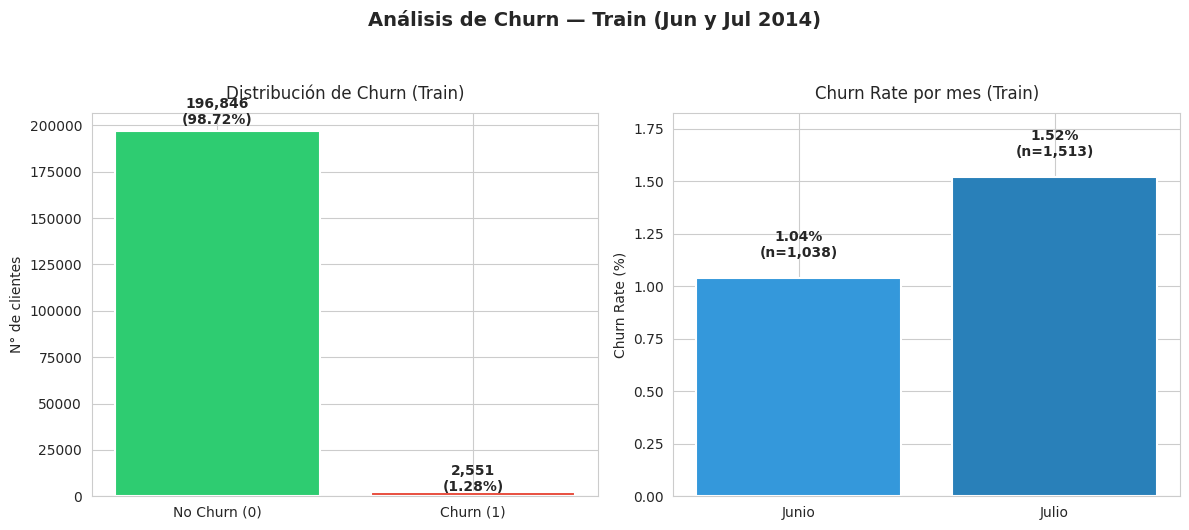

In [ ]:
import matplotlib.pyplot as plt

#Ajuste previo: Asegurarnos de que el índice sea comparable
# Agrupamos y convertimos el índice a string para que el mapeo funcione
churn_mes = (df_train_procesado
             .groupby('last_date_of_month')['churn']
             .agg(['sum', 'mean', 'count']))

# Convertimos el índice (que es datetime) a strings que coincidan con tus llaves
# o simplemente formateamos el índice directamente:
#churn_mes.index = churn_mes.index.strftime('%Y-%m-%d')

# Ahora el diccionario de mapeo debe usar el formato que tiene el índice
mes_labels = {'6/30/2014': 'Junio', '7/31/2014': 'Julio'}
churn_mes = churn_mes.rename(index=mes_labels)

# Gráfico 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 0: Distribución Total
churn_counts = df_train['churn'].value_counts().sort_index()
bars = axes[0].bar(
    ['No Churn (0)', 'Churn (1)'],
    churn_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribución de Churn (Train)', fontsize=12, pad=10)
axes[0].set_ylabel('N° de clientes')

for bar, v in zip(bars, churn_counts.values):
    pct = v / churn_counts.sum() * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        v + (v * 0.02), # Espaciado dinámico arriba de la barra
        f'{v:,}\n({pct:.2f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )

# Plot 1: Churn Rate por Mes
bars2 = axes[1].bar(
    churn_mes.index,
    churn_mes['mean'] * 100,
    color=['#3498db', '#2980b9'],
    edgecolor='white', linewidth=1.5
)
axes[1].set_title('Churn Rate por mes (Train)', fontsize=12, pad=10)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(churn_mes['mean'] * 100) * 1.2) # Espacio para el texto

for bar, (idx, row) in zip(bars2, churn_mes.iterrows()):
    pct = row['mean'] * 100
    n = int(row['sum'])
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        pct + 0.1,
        f'{pct:.2f}%\n(n={n:,})',
        ha='center', fontsize=10, fontweight='bold'
    )

plt.suptitle('Análisis de Churn — Train (Jun y Jul 2014)',
             fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Resumen: <br>
Se tiene un total de 199397 registro con un 1.28% de ratio de churn. Es decir el ratio de No churn y Churn es de aproximadamente 77x más No-churn que Churn. Este ratio es de suma imporatancia conocerlo para usarlo posteriormente. <br>
Adicionalmente, se tiene un churn rate mayor en Julio que en Junio.
A continuación se empezará a realizar un análisis univariado entre las variables y el target para analizar su comportamiento.

#### 4.1 Análisis univariado

In [ ]:
def num_univariate_analysis_temporal(data, column_names, scale='linear'):
    """
    Realiza un análisis univariado comparando el comportamiento mensual
    de variables numéricas entre clientes con y sin Churn y muestra estadísticas
    por estado de Churn.
    """
    # 1. Preparación de datos
    temp_data = data.copy()
    temp_data['last_date_of_month'] = pd.to_datetime(df['last_date_of_month'])
    # Creamos etiquetas para los gráficos
    temp_data['month_label'] = temp_data['last_date_of_month'].dt.strftime('%m-%Y').fillna('NaT / Fuga')
    # Creamos un sufijo numérico para el reporte estadístico (ej: arpu_6, arpu_7)
    temp_data['month_num'] = temp_data['last_date_of_month'].dt.month

    # Ordenar por la fecha real para que el gráfico tenga sentido cronológico
    temp_data = temp_data.sort_values(by='last_date_of_month', na_position='last')

    # PARTE GRÁFICA
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))

    for i, col in enumerate(column_names):
        sns.violinplot(x='month_label', y=col, hue='churn',
                       data=temp_data, split=True, ax=axes[i], palette="Set2")

        axes[i].set_title(f'{col} Evolución Mensual vs Churn')
        axes[i].set_xlabel('Mes del Registro')

        if scale == 'log':
            axes[i].set_yscale('log')
            axes[i].set_ylabel(f'{col} (Log Scale)')

        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # PARTE ESTADÍSTICA (REQUERIDA)
    # Iteramos por cada estado de Churn para generar los cuadros independientes
    for churn_val in [1, 0]:
        label_text = "FUGA (Churn : 1)" if churn_val == 1 else "NO FUGA (Churn : 0)"
        print(f"Clientes: {label_text}")

        # Filtramos por el estado de churn actual
        subset = temp_data[temp_data['churn'] == churn_val]

        # Para cada variable en column_names, transformamos de formato largo a ancho
        # para obtener las columnas tipo variable_6, variable_7, etc.
        stats_list = []
        for col in column_names:
            # Pivotamos para tener meses como columnas
            pivoted = subset.pivot(columns='month_num', values=col)
            # Renombramos las columnas al formato arpu_6, arpu_7, etc.
            # Ignoramos NaT para el reporte estadístico limpio de meses
            pivoted = pivoted[[6.0, 7.0]].dropna(axis=1, how='all')
            pivoted.columns = [f"{col}_{int(m)}" for m in pivoted.columns]
            stats_list.append(pivoted)

        # Concatenamos todas las variables pivotadas y calculamos el describe
        full_stats_df = pd.concat(stats_list, axis=1)
        print(full_wide_describe := full_stats_df.describe())
        print("\n" + "="*80 + "\n")

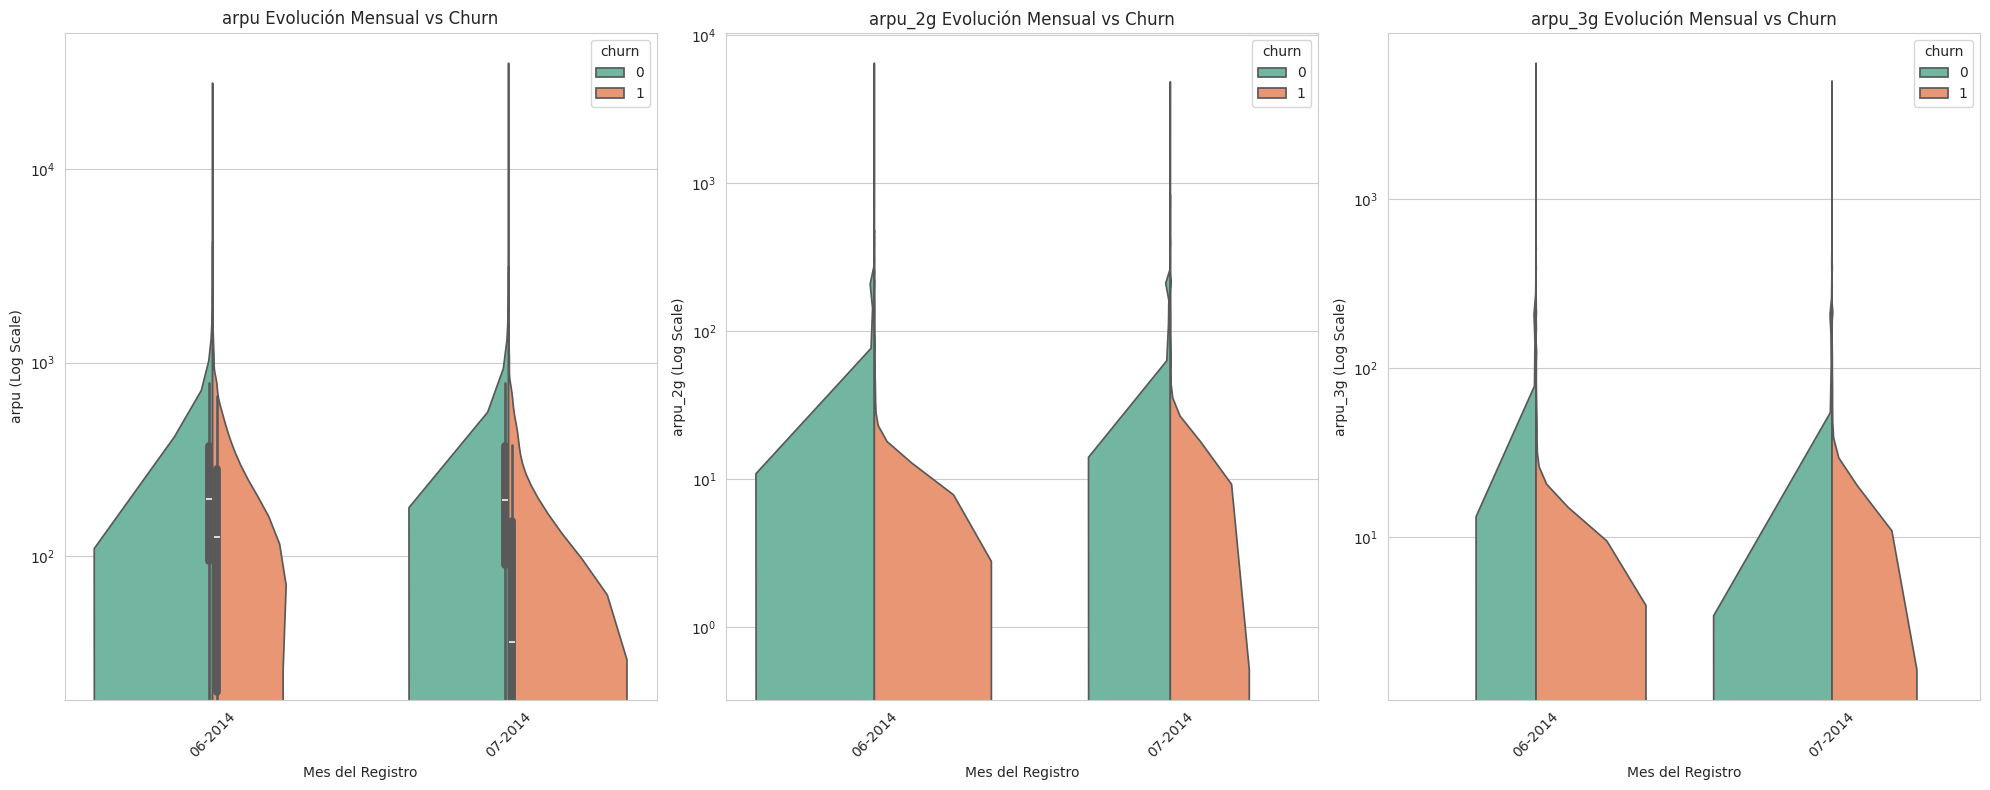

Clientes: FUGA (Churn : 1)
       arpu_6  arpu_7  arpu_2g_6  arpu_2g_7  arpu_3g_6  arpu_3g_7
count 1038.00 1513.00    1038.00    1513.00    1038.00    1513.00
mean   210.24  128.22       4.98       8.42       5.27       8.53
std    292.93  240.18      32.59      55.13      36.42      55.10
min    -97.10  -97.10      -1.18      -0.14      -0.03      -0.58
25%     20.00    0.00       0.00       0.00       0.00       0.00
50%    125.90   36.00       0.00       0.00       0.00       0.00
75%    280.69  151.70       0.00       0.00       0.00       0.00
max   4050.63 3037.67     466.68     811.93     510.97     862.32


Clientes: NO FUGA (Churn : 0)
        arpu_6   arpu_7  arpu_2g_6  arpu_2g_7  arpu_3g_6  arpu_3g_7
count 98961.00 97885.00   98961.00   97885.00   98961.00   97885.00
mean    283.75   282.57      21.91      22.31      22.71      23.22
std     328.71   339.24      94.83      97.51     104.82     107.35
min   -2258.71 -2014.05     -35.83     -15.48     -30.82     -26.04
25%    

In [61]:
num_univariate_analysis_temporal(df_train_procesado, ['arpu', 'arpu_2g', 'arpu_3g'], scale='log')

In [62]:
# Clientes que aparecen en AMBOS meses
clientes_junio = set(df_train_procesado[df_train_procesado['last_date_of_month'] == '6/30/2014']['mobile_number'])
clientes_julio = set(df_train_procesado[df_train_procesado['last_date_of_month'] == '7/31/2014']['mobile_number'])
clientes_ambos = clientes_junio & clientes_julio

# Filtrar solo los que están en ambos meses
df_junio = df_train_procesado[
    (df_train_procesado['last_date_of_month'] == '6/30/2014') &
    (df_train_procesado['mobile_number'].isin(clientes_ambos))
][['mobile_number', 'arpu', 'churn']].rename(
    columns={'arpu': 'arpu_jun', 'churn': 'churn_jul_real'}
)

df_julio = df_train_procesado[
    (df_train_procesado['last_date_of_month'] == '7/31/2014') &
    (df_train_procesado['mobile_number'].isin(clientes_ambos))
][['mobile_number', 'arpu', 'churn']].rename(
    columns={'arpu': 'arpu_jul', 'churn': 'churn_julio'}
)
df_evolucion = df_junio.merge(df_julio, on='mobile_number')
resumen = df_evolucion.groupby('churn_julio')[['arpu_jun', 'arpu_jul']].mean()
resumen['caida_pct'] = ((resumen['arpu_jul'] - resumen['arpu_jun']) /
                         resumen['arpu_jun'] * 100)
resumen.index = resumen.index.map({0: 'No Churn en Jul', 1: 'Churn en Jul'})

print('\nEvolución ARPU del MISMO cliente de Jun a Jul:')
print(resumen.round(2))


Evolución ARPU del MISMO cliente de Jun a Jul:
                 arpu_jun  arpu_jul  caida_pct
churn_julio                                   
No Churn en Jul    282.28    282.57       0.10
Churn en Jul       344.24    128.22     -62.75


Se puede observar que el Arpu de los clientes que van a hacer churn tiende a decrecer de un mes a otro comparado con aquellos que no hacen churn. <br>
Se podría concluir que aquellos clientes que, comparando un mes versus el otro, el ARPU decrece de manera muy abrupta (50-70%) es muy probable que cometa churn versus aquellos que mantienen o incrementan su ARPU. <br>
Adicionalmente se puede observar que al menos el 25% de clientes que van a hacer churn en julio ya no generan ingreso (ARPU p25= 0)

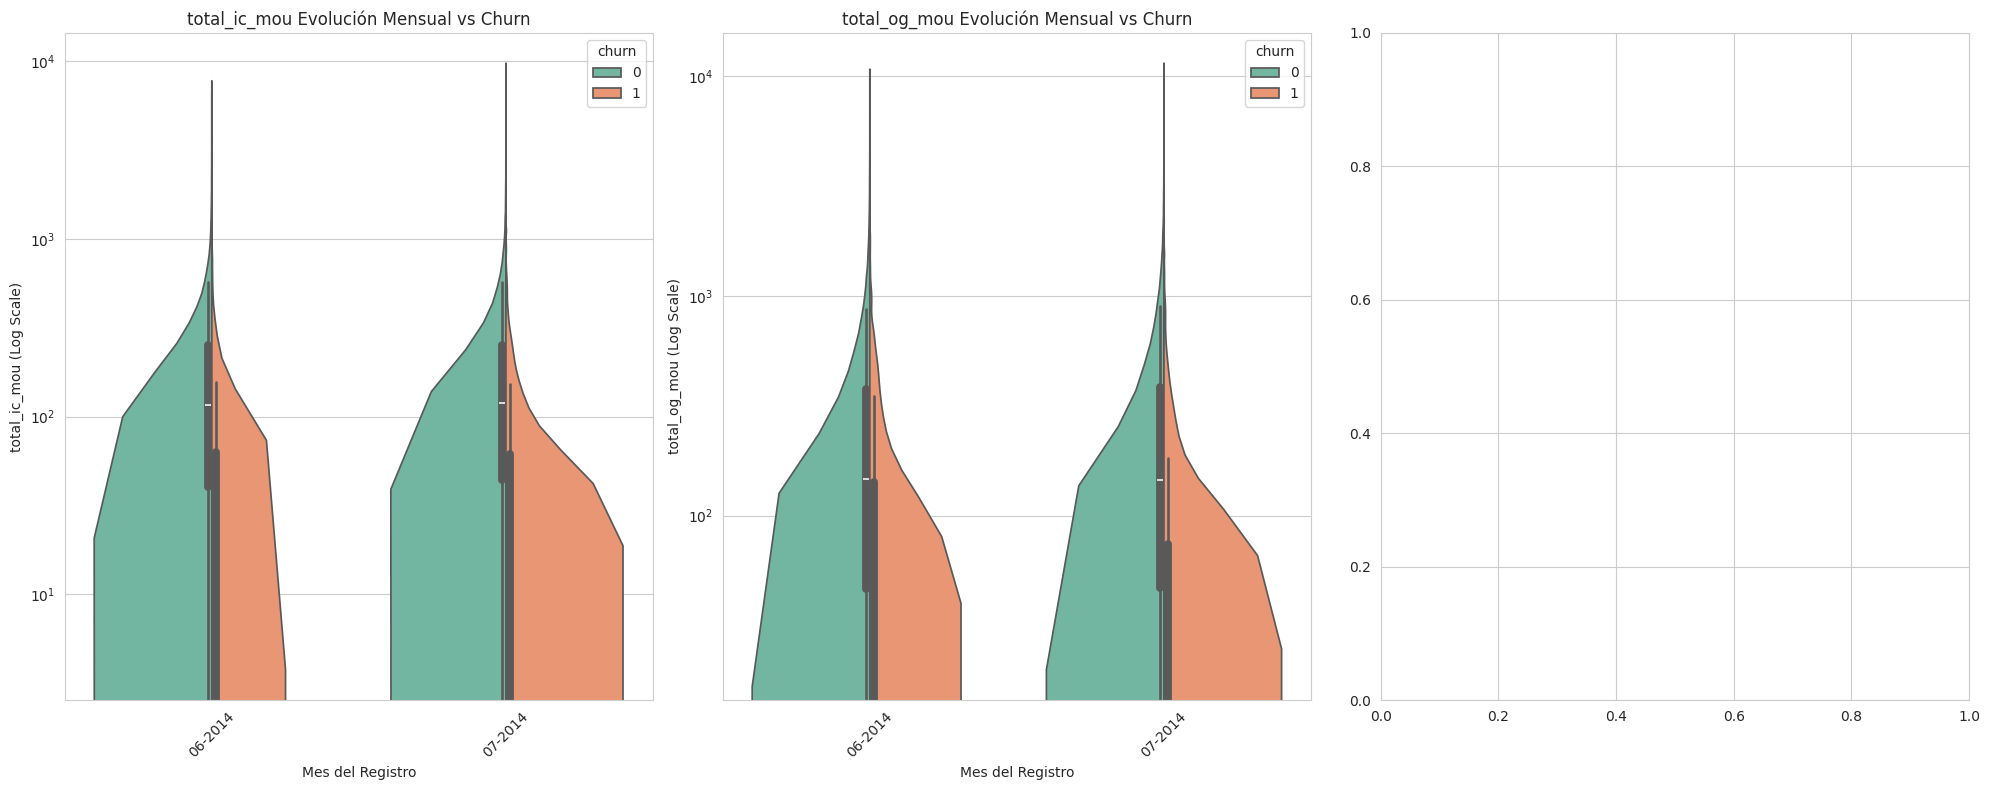

Clientes: FUGA (Churn : 1)
       total_ic_mou_6  total_ic_mou_7  total_og_mou_6  total_og_mou_7
count         1038.00         1513.00         1038.00         1513.00
mean            68.46           64.86          143.01          107.67
std            272.20          160.79          324.66          301.01
min              0.00            0.00            0.00            0.00
25%              0.00            0.00            0.00            0.00
50%              0.00            0.00            0.00            0.00
75%             62.93           61.71          141.58           74.06
max           6633.18         2155.56         3669.83         3778.94


Clientes: NO FUGA (Churn : 0)
       total_ic_mou_6  total_ic_mou_7  total_og_mou_6  total_og_mou_7
count        98961.00        97885.00        98961.00        97885.00
mean           201.51          206.23          306.83          315.27
std            291.54          299.73          464.36          482.45
min              0.00          

In [63]:
num_univariate_analysis_temporal(df_train_procesado, ['total_ic_mou','total_og_mou'], scale='log')

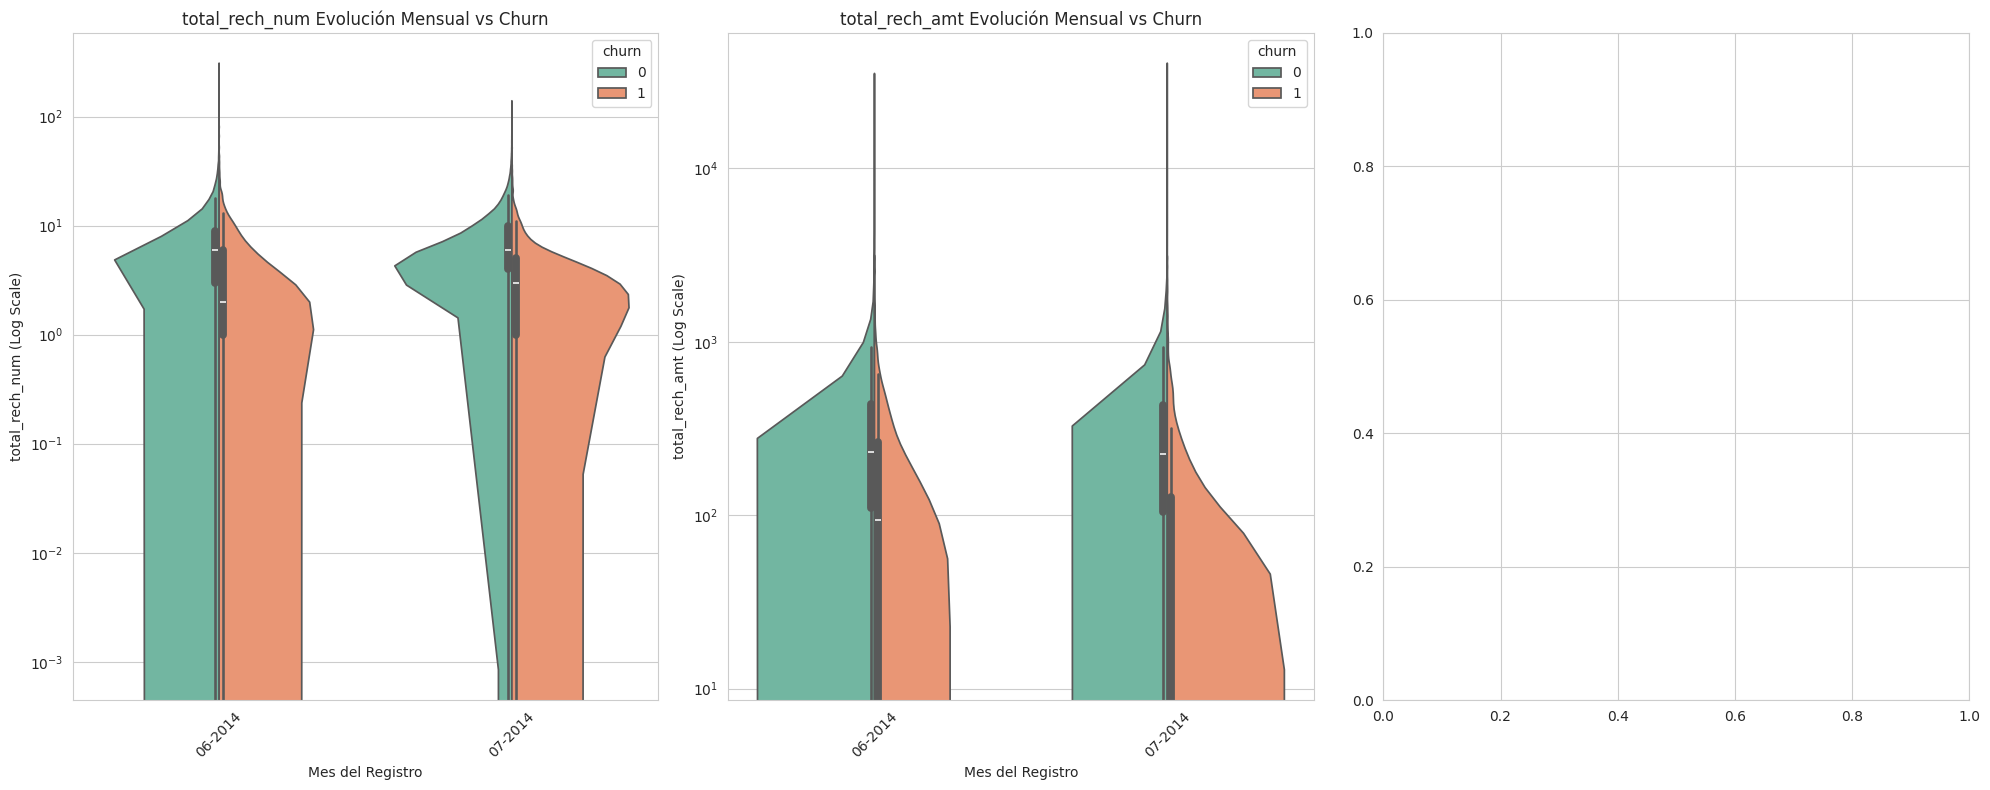

Clientes: FUGA (Churn : 1)
       total_rech_num_6  total_rech_num_7  total_rech_amt_6  total_rech_amt_7
count           1038.00           1513.00           1038.00           1513.00
mean               4.50              3.86            191.33            119.85
std                6.54              4.82            289.07            256.73
min                0.00              0.00              0.00              0.00
25%                1.00              1.00              0.00              0.00
50%                2.00              3.00             93.50              0.00
75%                6.00              5.00            263.50            127.00
max               80.00             52.00           3015.00           3019.00


Clientes: NO FUGA (Churn : 0)
       total_rech_num_6  total_rech_num_7  total_rech_amt_6  total_rech_amt_7
count          98961.00          97885.00          98961.00          97885.00
mean               7.59              7.81            328.94            328.09
std  

In [64]:
num_univariate_analysis_temporal(df_train_procesado, ['total_rech_num','total_rech_amt'], scale='log')

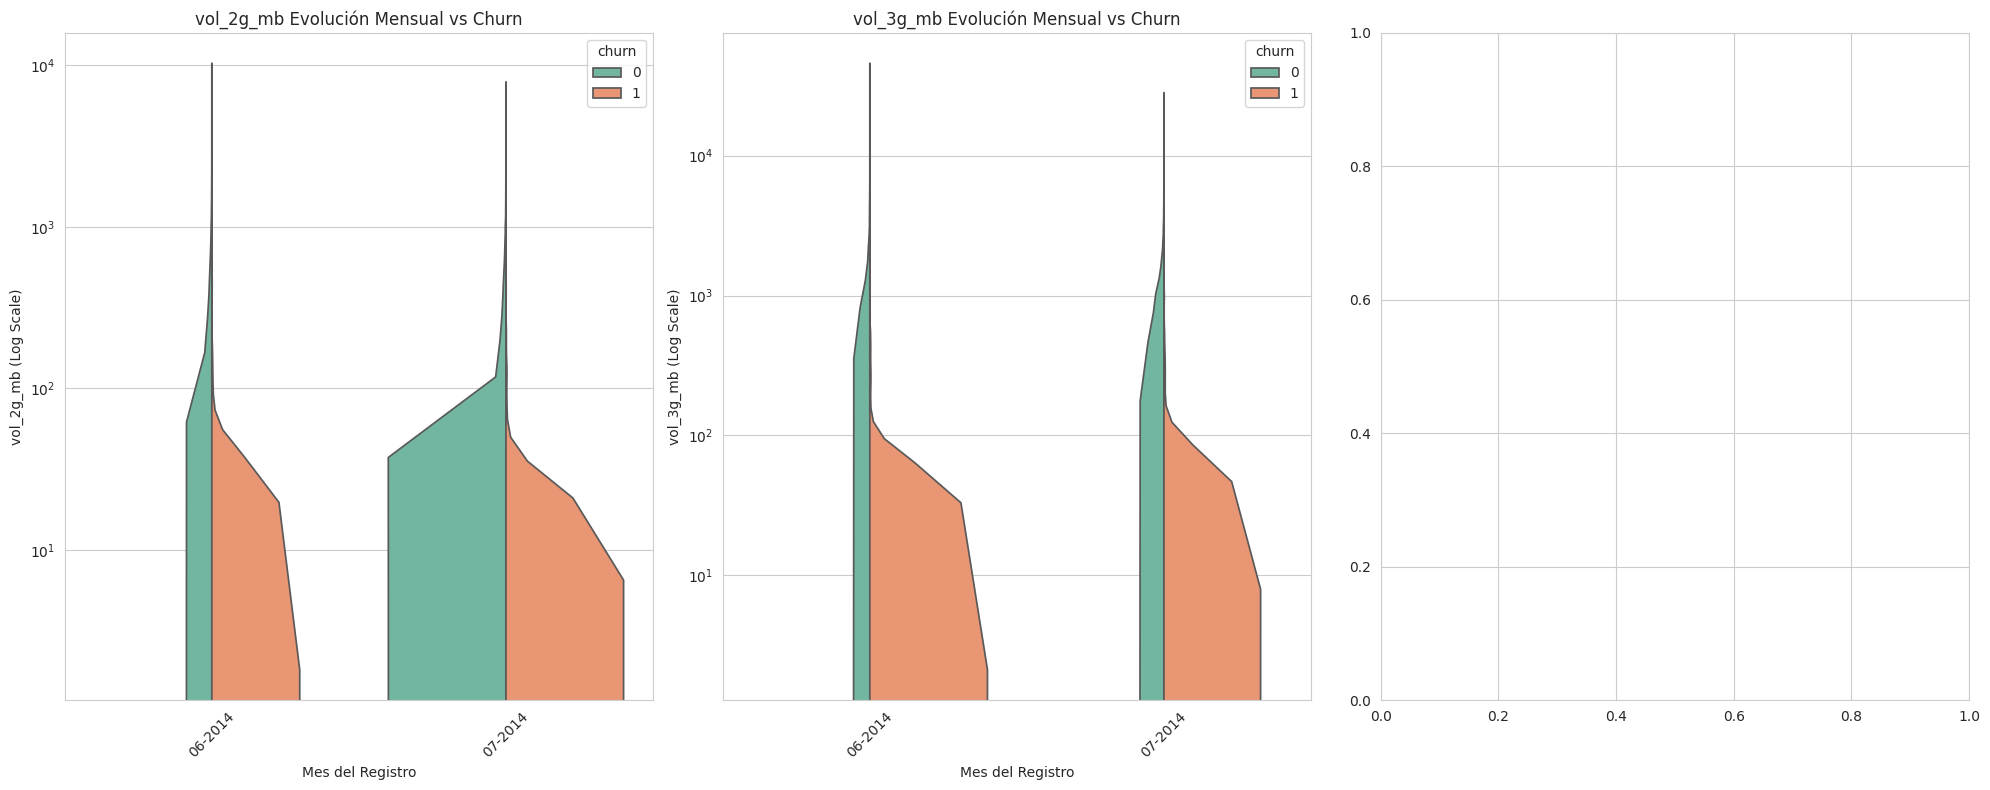

Clientes: FUGA (Churn : 1)
       vol_2g_mb_6  vol_2g_mb_7  vol_3g_mb_6  vol_3g_mb_7
count      1038.00      1513.00      1038.00      1513.00
mean         15.64        11.63        29.60        38.98
std         103.96        79.73       181.65       234.73
min           0.00         0.00         0.00         0.00
25%           0.00         0.00         0.00         0.00
50%           0.00         0.00         0.00         0.00
75%           0.00         0.00         0.00         0.00
max        1666.73      1357.35      2877.78      3627.46


Clientes: NO FUGA (Churn : 0)
       vol_2g_mb_6  vol_2g_mb_7  vol_3g_mb_6  vol_3g_mb_7
count     98961.00     97885.00     98961.00     97885.00
mean         52.29        52.16       122.36       131.18
std         214.18       214.26       546.70       546.32
min           0.00         0.00         0.00         0.00
25%           0.00         0.00         0.00         0.00
50%           0.00         0.00         0.00         0.00
75%          

In [65]:
num_univariate_analysis_temporal(df_train_procesado, ['vol_2g_mb','vol_3g_mb'], scale='log')

Tras analizar las variables numéricas se tiene los siguientes insights:


1.   Los churners tienen una caida marcada >= 50% en su ARPU de un mes al otro y al menos 1 de cada 4 de estos ya no generan revenue.
2.   Con respecto al uso de minutos saliente y entrantes, los p25 y p50, los churners tienen una marcada inactividad total a diferencia de los no churners.
3.   Al tomar las recargas en cantidad y monto, se observa que los churners recargan la mitad de veces que los no churners (4 vs 8) y el p50% nos indica que por lo menos la mitad de los churners recarga muy poco en monto o nada a comparación de los no churners.
4.   Finalmente con respecto al uso de datos, los churners usan 5 veces menos en promedio versus los no churners.


In [ ]:
# Análisis univariado

# Separar churners y no churners en train
churned     = df_train_procesado[df_train_procesado['churn'] == 1]
non_churned = df_train_procesado[df_train_procesado['churn'] == 0]

def cat_univariate_analysis(column_names, df=df_train_procesado, figsize=(16, 4)):

    # ── Gráficos ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(column_names), figsize=figsize)
    if len(column_names) == 1:
        axes = [axes]

    for ax, col in zip(axes, column_names):
        sns.countplot(
            x=col, hue='churn', data=df, ax=ax,
            palette={0: '#2ecc71', 1: '#e74c3c'}
        )
        ax.set_title(f'{col} vs Churn', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('N° clientes')
        ax.legend(title='Churn', labels=['No (0)', 'Sí (1)'], loc='upper right')

    plt.suptitle('Distribución de variables categóricas por Churn',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    #Tabla de frecuencias por grupo 
    for col in column_names:
        print(f'\n{"="*60}')
        print(f'Variable: {col}')
        print(f'{"="*60}')

        # Churners
        freq_churn = (churned[col]
                      .value_counts()
                      .rename_axis(col)
                      .reset_index(name='n'))
        freq_churn['%']          = (freq_churn['n'] / freq_churn['n'].sum() * 100).round(2)
        freq_churn['% acum']     = freq_churn['%'].cumsum().round(2)

        # No churners
        freq_no_churn = (non_churned[col]
                         .value_counts()
                         .rename_axis(col)
                         .reset_index(name='n'))
        freq_no_churn['%']       = (freq_no_churn['n'] / freq_no_churn['n'].sum() * 100).round(2)
        freq_no_churn['% acum']  = freq_no_churn['%'].cumsum().round(2)

        # Churn rate por valor
        churn_rate = (df_train_procesado.groupby(col)['churn']
                      .mean()
                      .mul(100)
                      .round(2)
                      .rename('churn_rate%')
                      .reset_index())

        print(f'\nChurners (churn=1) — n={len(churned):,}')
        print(freq_churn.to_string(index=False))

        print(f'\nNo Churners (churn=0) — n={len(non_churned):,}')
        print(freq_no_churn.to_string(index=False))

        print(f'\nChurn rate por valor de {col}:')
        print(churn_rate.to_string(index=False))

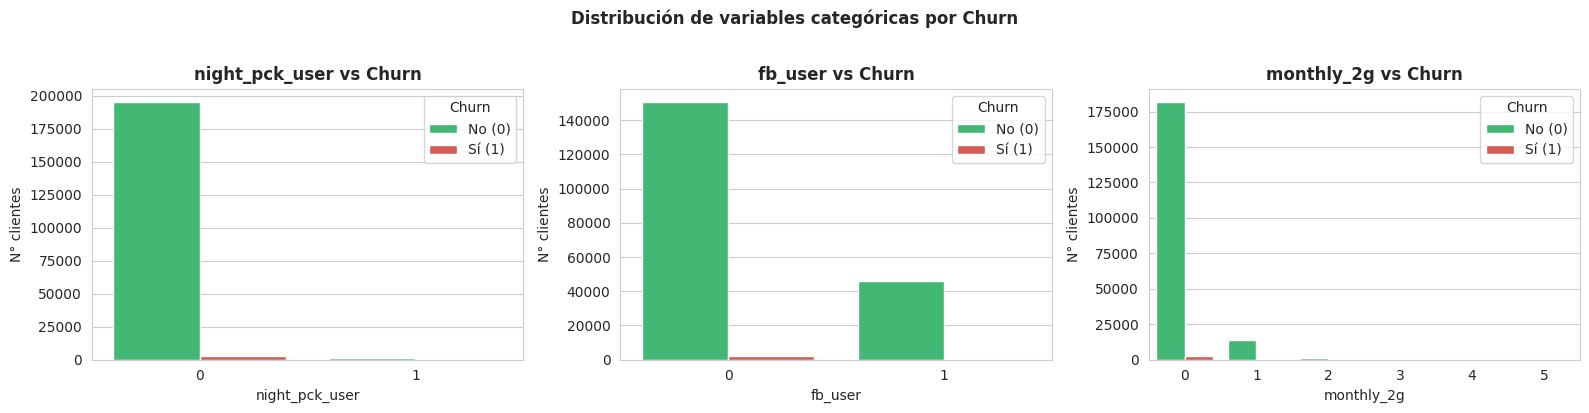


Variable: night_pck_user

Churners (churn=1) — n=2,551
night_pck_user    n     %  % acum
             0 2546 99.80   99.80
             1    5  0.20  100.00

No Churners (churn=0) — n=196,846
night_pck_user      n     %  % acum
             0 195631 99.38   99.38
             1   1215  0.62  100.00

Churn rate por valor de night_pck_user:
night_pck_user  churn_rate%
             0         1.28
             1         0.41

Variable: fb_user

Churners (churn=1) — n=2,551
fb_user    n     %  % acum
      0 2317 90.83   90.83
      1  234  9.17  100.00

No Churners (churn=0) — n=196,846
fb_user      n     %  % acum
      0 150842 76.63   76.63
      1  46004 23.37  100.00

Churn rate por valor de fb_user:
fb_user  churn_rate%
      0         1.51
      1         0.51

Variable: monthly_2g

Churners (churn=1) — n=2,551
monthly_2g    n     %  % acum
         0 2508 98.31   98.31
         1   38  1.49   99.80
         2    5  0.20  100.00
         3    0  0.00  100.00
         4    0  0.00  

/tmp/ipykernel_1211/2832280483.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = (df_train_procesado.groupby(col)['churn']
/tmp/ipykernel_1211/2832280483.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = (df_train_procesado.groupby(col)['churn']
/tmp/ipykernel_1211/2832280483.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = (df_train_procesado.groupby(col)['churn']


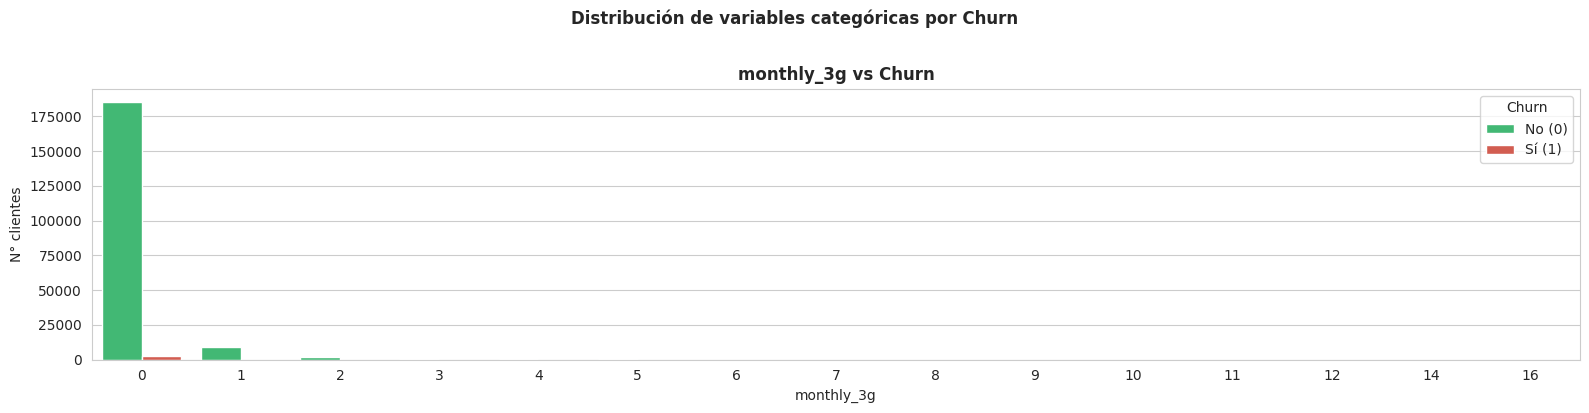


Variable: monthly_3g

Churners (churn=1) — n=2,551
monthly_3g    n     %  % acum
         0 2504 98.16   98.16
         1   41  1.61   99.77
         2    5  0.20   99.97
         3    1  0.04  100.01
         4    0  0.00  100.01
         5    0  0.00  100.01
         6    0  0.00  100.01
         7    0  0.00  100.01
         8    0  0.00  100.01
         9    0  0.00  100.01
        10    0  0.00  100.01
        11    0  0.00  100.01
        12    0  0.00  100.01
        14    0  0.00  100.01
        16    0  0.00  100.01

No Churners (churn=0) — n=196,846
monthly_3g      n     %  % acum
         0 185511 94.24   94.24
         1   8694  4.42   98.66
         2   1872  0.95   99.61
         3    463  0.24   99.85
         4    150  0.08   99.93
         5     76  0.04   99.97
         6     38  0.02   99.99
         7     19  0.01  100.00
         8      8  0.00  100.00
         9      6  0.00  100.00
        11      4  0.00  100.00
        14      2  0.00  100.00
        10      1

/tmp/ipykernel_1211/2832280483.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = (df_train_procesado.groupby(col)['churn']


In [67]:
cat_univariate_analysis(['night_pck_user', 'fb_user', 'monthly_2g'])
cat_univariate_analysis(['monthly_3g'])

Tras analizar las variables categoricas se tienen los siguientes insights:


1.   night_pck_user: casi el 100% de los churners no usan paquetes nocturnos y además de churn vesus los que si usan es de 0.41% versus el 1.28% de los que no usan.
2.   fb_user: Existe un churn rate de 1.53% sobre los clientes que no usan versus un 0.51% de los clientes que usan. Es decir, usar datos de redes sociales o en otras palabaras un cliente con uso de facebook tiene 3 veces menos probabilidad de hace churn.

3.   monthly_2g y monthly_3g: Se puede observar que tener al menos un paquete mensual activo, reduce el churn en por lo menos a la mitad (0 -> 1.33% churn versus > 1 -> 0.47%, 0.27%...)



#### 4.2 Análisis bivariado

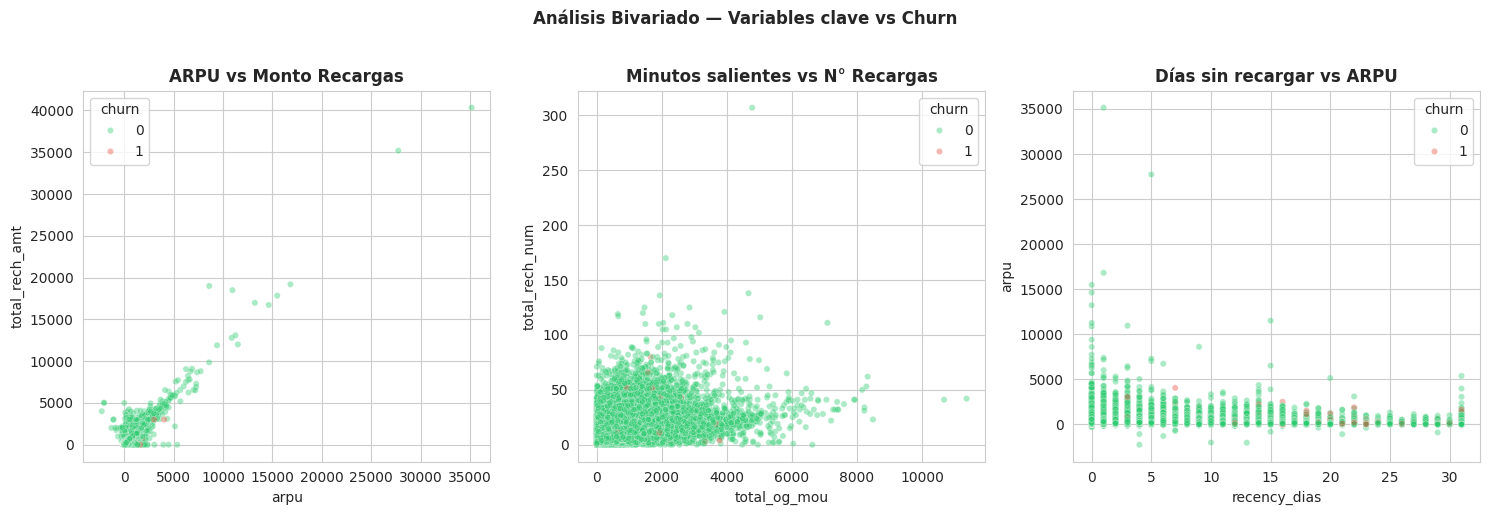

In [ ]:
# Análisis bivariado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pares = [
    ('arpu',           'total_rech_amt',  'ARPU vs Monto Recargas'),
    ('total_og_mou',   'total_rech_num',  'Minutos salientes vs N° Recargas'),
    ('recency_dias',   'arpu',            'Días sin recargar vs ARPU'),
]

for ax, (x, y, titulo) in zip(axes, pares):
    muestra = df_train_procesado.sample(len(df_train_procesado), random_state=42)
    sns.scatterplot(
        x=x, y=y, hue='churn',
        data=muestra, ax=ax,
        palette={0: '#2ecc71', 1: '#e74c3d'},
        alpha=0.4, s=20
    )
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('Análisis Bivariado — Variables clave vs Churn',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Se obtuvieron los siguientes insights:

**Gráfico 1: ARPU vs Monto Recargas**
Los churners (naranja) se concentran en la esquina
inferior izquierda: bajo ARPU y bajo monto de recarga
simultáneamente. No hay churners con ARPU alto y
recargas altas. La combinación de ambas variables
baja separa bien a los churners del resto.
→ Un cliente con ARPU < 500 Y recargas < 500
  podría interpretarse como un perfil potencial de churn.

**Gráfico 2: Minutos salientes vs N° Recargas**
Hay dos patrones en churners:
1. Clientes con muy pocos minutos y pocas recargas
   → inactivos totales, churn por abandono
2. Algunos churners tienen recargas altas pero
   pocos minutos → recargan pero no llaman.

**Gráfico 3: Días sin recargar vs ARPU**
Confirma lo visualizado en la variable recency_dias:
- Churners tienen alta recencia (más días sin recargar)
  y bajo ARPU simultáneamente
- No churners con ARPU alto recargan frecuentemente
  (recency_dias cercano a 0)
- Los outliers de ARPU alto son todos no churners
→ La combinación recencia alta + ARPU bajo es la
  una señal clara de riesgo de fuga.

### 4.3 Análisis correlaciones

In [157]:
df_train_procesado.head()

,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number,uso_total_datos_mb,uso_total_voz_mou,recency_dias,Cluster_RFM
99999,7/31/2014,214.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,252,252,2014-07-16,252,2014-07-16,1.00,252.00,0.00,1.00,252.00,1.32,150.76,212.17,212.17,0,0,0,1,0,1,0,7000842753,152.08,0.00,15.00,3
100000,7/31/2014,355.07,78.68,99.84,0.00,0.00,74.56,75.94,0.00,2.91,150.51,4.11,0.46,0.00,4.58,0.00,23.43,0.00,178.53,29.91,65.38,8.93,104.23,0.00,0.00,0.00,0.00,104.23,0.00,0.00,0.00,9,384,154,2014-07-31,23,2014-07-25,1.00,154.00,1.00,0.00,154.00,108.07,0.00,0.00,28.61,0,1,0,0,0,1,0,7001865778,108.07,282.76,0.00,0
100001,7/31/2014,189.06,55.24,220.59,0.00,0.00,28.74,16.86,21.79,135.54,67.41,26.49,67.41,14.76,108.68,0.00,236.84,0.00,412.94,71.11,15.44,122.29,208.86,71.29,177.01,58.34,306.66,519.53,0.00,0.85,3.14,4,315,200,2014-07-24,200,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7001625959,0.00,932.47,7.00,0
100002,7/31/2014,251.10,54.39,109.01,54.86,28.09,34.81,83.21,0.65,0.00,118.68,14.89,1.73,0.00,16.63,0.00,0.00,0.00,135.31,19.98,64.51,27.09,111.59,66.44,38.56,0.00,105.01,216.61,0.00,0.00,0.00,11,310,50,2014-07-31,50,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7001204172,0.00,351.92,0.00,0
100003,7/31/2014,309.88,149.44,91.88,0.00,0.00,149.44,91.88,0.00,0.00,241.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,241.33,88.49,109.54,0.00,198.04,0.00,0.25,0.00,0.25,198.29,0.00,0.00,0.00,6,350,110,2014-07-28,110,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7000142493,0.00,439.62,3.00,0


In [ ]:
# Correlaciones separadas por grupo churn
churned     = df_train_procesado[df_train_procesado['churn'] == 1]
non_churned = df_train_procesado[df_train_procesado['churn'] == 0]

def get_correlations(df, threshold=0.5):
    cols = [c for c in df.select_dtypes(include='number').columns
            if c not in ['churn', 'mobile_number']]
    corr = df[cols].corr().abs()

    corr_df = (corr.unstack()
                   .reset_index()
                   .rename(columns={'level_0':'VAR1','level_1':'VAR2', 0:'CORR'}))
    corr_df['CORR'] = corr_df['CORR'].round(3)
    corr_df = corr_df[corr_df['VAR1'] != corr_df['VAR2']]
    corr_df['par'] = corr_df.apply(
        lambda r: '-'.join(sorted([r['VAR1'], r['VAR2']])), axis=1
    )
    corr_df = corr_df.drop_duplicates('par')[['VAR1','VAR2','CORR']]
    return corr_df[corr_df['CORR'] >= threshold].sort_values('CORR', ascending=False)

cor_churn    = get_correlations(churned,     threshold=0.4)
cor_no_churn = get_correlations(non_churned, threshold=0.4)

print(f"Pares con correlación >= 0.5 en CHURNERS:     {len(cor_churn)}")
print(f"Pares con correlación >= 0.5 en NO CHURNERS:  {len(cor_no_churn)}")
print()
print("Top 20 correlaciones en CHURNERS:")
print(cor_churn.head(30).to_string(index=False))
print()
print("Top 20 correlaciones en NO CHURNERS:")
print(cor_no_churn.head(30).to_string(index=False))

Pares con correlación >= 0.5 en CHURNERS:     110
Pares con correlación >= 0.5 en NO CHURNERS:  102

Top 20 correlaciones en CHURNERS:
            VAR1               VAR2  CORR
   count_rech_2g          sachet_2g  0.98
       onnet_mou     std_og_t2t_mou  0.97
  loc_og_t2m_mou         loc_og_mou  0.95
       vol_3g_mb uso_total_datos_mb  0.93
   count_rech_3g          sachet_3g  0.92
      std_og_mou       total_og_mou  0.92
      loc_ic_mou       total_ic_mou  0.92
         arpu_3g            arpu_2g  0.91
            arpu     total_rech_amt  0.91
  std_ic_t2m_mou         std_ic_mou  0.91
   max_rech_data   av_rech_amt_data  0.91
 total_rech_data      count_rech_2g  0.89
      offnet_mou     std_og_t2m_mou  0.89
 total_rech_data          sachet_2g  0.88
    total_og_mou  uso_total_voz_mou  0.88
  loc_ic_t2m_mou         loc_ic_mou  0.86
      offnet_mou       total_og_mou  0.84
  loc_ic_t2t_mou         loc_ic_mou  0.84
av_rech_amt_data uso_total_datos_mb  0.83
av_rech_amt_data         

In [ ]:
# Eliminar variables redundantes por construcción
cols_eliminar = [
    # Creadas como suma exacta → correlación ~0.88-0.93 con sus componentes
    'uso_total_voz_mou',    # = total_og_mou + total_ic_mou
    'uso_total_datos_mb',   # = vol_2g_mb + vol_3g_mb
]

df_train_procesado = df_train_procesado.drop(columns=cols_eliminar)
df_test_procesado  = df_test_procesado.drop(columns=cols_eliminar)

print(f"Eliminadas: {cols_eliminar}")
print(f"Shape train: {df_train_procesado.shape}")

Eliminadas: ['uso_total_voz_mou', 'uso_total_datos_mb']
Shape train: (199397, 56)


### Decisión sobre correlaciones
Se identificaron ~110 pares con correlación ≥ 0.5 en churners.
Los pares con correlación más alta corresponden a dos casos:

**1. Variables redundantes por construcción (se eliminan):**
- uso_total_voz_mou (= total_og_mou + total_ic_mou, corr=0.88)
- uso_total_datos_mb (= vol_2g_mb + vol_3g_mb, corr=0.93)
Estas son combinaciones de variables ya presentes usadas parafacilitar la segmentación de clustering. Se eliminarán por redudancia.

**2. Variables correlacionadas pero que conceptualmente tienen definiciones distintas. Por ejemplo:**

- count_rech_2g / sachet_2g (0.98): recargas vs paquetes
- arpu / total_rech_amt (0.91): revenue vs pago efectivo
- arpu_2g / arpu_3g (0.91): revenue por tipo de red

Estas se mantendrán debido a que se piensan emplear modelos de arboles que manejan con robustez la multicolinealidad.

### 4.4 Análisis de outliers

In [216]:
df_train_nooutliers = df_train_procesado.copy()
df_test_nooutliers = df_test_procesado.copy()

In [ ]:
# Detección y tratamiento de outliers
# Estrategia: capping al P99 (winsorizing)
# - No elimina filas, solo limita valores extremos
# - Umbral calculado SOLO sobre train, aplicado a train y test
# - Solo se aplicará a variables numéricas continuas

# Columnas a analizar (excluir ids, target, flags binarios y deltas pct)
cols_excluir = [
    'mobile_number', 'churn', 'last_date_of_month',
    'date_of_last_rech', 'date_of_last_rech_data',
    'night_pck_user', 'fb_user', 'Cluster_RFM',
    'arpu_segment_num',
]

cols_numericas = [
    c for c in df_train_nooutliers.select_dtypes(include='number').columns
    if c not in cols_excluir
]

print(f"Columnas a analizar: {len(cols_numericas)}")

Columnas a analizar: 46


In [218]:
# ── Detectar outliers: salto > 100% entre P99 y P100 ─────────────────────
percentiles = df_train_nooutliers[cols_numericas].quantile(
    [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00]
)

# Cambio porcentual entre P99 y P100
pct_change = percentiles.pct_change().mul(100).iloc[-1]

# Columnas con salto > 100% (el máximo es más del doble del P99)
outlier_cols = pct_change[pct_change > 100].index.tolist()
outlier_cols = [c for c in outlier_cols if c in cols_numericas]

print(f"Columnas con outliers extremos: {len(outlier_cols)}")
print()
print(f"{'Columna':<30} {'P99':>10}  {'Max':>12}  {'Salto%':>8}")
print("─" * 65)
for col in outlier_cols:
    p99  = df_train_nooutliers[col].quantile(0.99)
    pmax = df_train_nooutliers[col].max()
    salto = ((pmax - p99) / (abs(p99) + 1)) * 100
    print(f"{col:<30} {p99:>10.1f}  {pmax:>12.1f}  {salto:>7.0f}%")

Columnas con outliers extremos: 45

Columna                               P99           Max    Salto%
─────────────────────────────────────────────────────────────────
arpu                               1421.1       35145.8     2371%
onnet_mou                          1439.7        8157.8      466%
offnet_mou                         1521.9        9667.1      535%
roam_ic_mou                         184.4       15371.0     8190%
roam_og_mou                         250.9        3775.1     1399%
loc_og_t2t_mou                      533.0        7400.7     1286%
loc_og_t2m_mou                      729.9        4729.7      547%
loc_og_t2f_mou                       54.2        1466.0     2560%
loc_og_t2c_mou                       21.5         916.2     3975%
loc_og_mou                         1134.3       10643.4      838%
std_og_t2t_mou                     1231.0        8133.7      560%
std_og_t2m_mou                     1229.9        9284.7      654%
std_og_t2f_mou                       24.

In [ ]:
# Aplicar capping al P99
# Calculado sobre train, aplicado a train y test
reporte = []

for col in outlier_cols:
    # Umbral calculado solo sobre train
    p99 = df_train_nooutliers[col].quantile(0.99)

    # Contar outliers
    n_train = (df_train_nooutliers[col] > p99).sum()
    n_test  = (df_test_nooutliers[col] > p99).sum() if col in df_test_nooutliers.columns else 0

    # Aplicar capping
    df_train_nooutliers [col] = df_train_nooutliers[col].clip(upper=p99)
    if col in df_test_nooutliers.columns:
        df_test_nooutliers[col] = df_test_nooutliers[col].clip(upper=p99)

    reporte.append({
        'columna'      : col,
        'umbral_p99'   : round(p99, 2),
        'caps_train'   : n_train,
        'caps_test'    : n_test,
    })

df_reporte = pd.DataFrame(reporte)
print(f"Reporte de capping:")
print(df_reporte.to_string(index=False))
print(f"\nTotal registros modificados train: {df_reporte['caps_train'].sum():,}")
print(f"Total registros modificados test : {df_reporte['caps_test'].sum():,}")

Reporte de capping:
         columna  umbral_p99  caps_train  caps_test
            arpu     1421.11        1994       1083
       onnet_mou     1439.65        1994       1023
      offnet_mou     1521.94        1994        953
     roam_ic_mou      184.43        1994        816
     roam_og_mou      250.92        1994        812
  loc_og_t2t_mou      532.99        1994        945
  loc_og_t2m_mou      729.87        1994        974
  loc_og_t2f_mou       54.16        1994        972
  loc_og_t2c_mou       21.51        1993       1207
      loc_og_mou     1134.34        1994        933
  std_og_t2t_mou     1230.99        1994       1042
  std_og_t2m_mou     1229.95        1994        950
  std_og_t2f_mou       24.60        1994        936
      std_og_mou     1864.50        1994       1044
      isd_og_mou        7.83        1991        906
      spl_og_mou       55.33        1992       1135
       og_others        4.94        1993         64
    total_og_mou     2243.01        1994    

In [ ]:
# Verificación: ya no deben existir saltos extremos
percentiles_post = df_train_nooutliers[outlier_cols].quantile(
    [0.99, 1.00]
)
pct_change_post = percentiles_post.pct_change().mul(100).iloc[-1]
casos_restantes = pct_change_post[pct_change_post > 100]

print(f"Columnas con outliers restantes: {len(casos_restantes)}")
print(f"(esperado: 0)")

Columnas con outliers restantes: 0
(esperado: 0)


In [ ]:
# Verificación: ya no deben existir saltos extremos
percentiles_post = df_test_nooutliers[outlier_cols].quantile(
    [0.99, 1.00]
)
pct_change_post = percentiles_post.pct_change().mul(100).iloc[-1]
casos_restantes = pct_change_post[pct_change_post > 100]

print(f"Columnas con outliers restantes: {len(casos_restantes)}")
print(f"(esperado: 0)")

Columnas con outliers restantes: 1
(esperado: 0)


In [222]:
print(df_train_nooutliers.shape), print(df_test_nooutliers.shape)

(199397, 56)
(98899, 56)


(None, None)

In [223]:
df_train_nooutliers.head()

,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,monthly_2g,sachet_2g,monthly_3g,sachet_3g,fb_user,churn,mobile_number,recency_dias,Cluster_RFM
99999,7/31/2014,214.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,252,252,2014-07-16,252,2014-07-16,1.00,252.00,0.00,1.00,252.00,1.32,150.76,212.17,212.17,0,0,0,1,0,1,0,7000842753,15.00,3
100000,7/31/2014,355.07,78.68,99.84,0.00,0.00,74.56,75.94,0.00,2.91,150.51,4.11,0.46,0.00,4.58,0.00,23.43,0.00,178.53,29.91,65.38,8.93,104.23,0.00,0.00,0.00,0.00,104.23,0.00,0.00,0.00,9,384,154,2014-07-31,23,2014-07-25,1.00,154.00,1.00,0.00,154.00,108.07,0.00,0.00,28.61,0,1,0,0,0,1,0,7001865778,0.00,0
100001,7/31/2014,189.06,55.24,220.59,0.00,0.00,28.74,16.86,21.79,21.51,67.41,26.49,67.41,14.76,108.68,0.00,55.33,0.00,412.94,71.11,15.44,122.29,208.86,71.29,177.01,40.96,306.66,519.53,0.00,0.85,3.14,4,315,200,2014-07-24,200,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7001625959,7.00,0
100002,7/31/2014,251.10,54.39,109.01,54.86,28.09,34.81,83.21,0.65,0.00,118.68,14.89,1.73,0.00,16.63,0.00,0.00,0.00,135.31,19.98,64.51,27.09,111.59,66.44,38.56,0.00,105.01,216.61,0.00,0.00,0.00,11,310,50,2014-07-31,50,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7001204172,0.00,0
100003,7/31/2014,309.88,149.44,91.88,0.00,0.00,149.44,91.88,0.00,0.00,241.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,241.33,88.49,109.54,0.00,198.04,0.00,0.25,0.00,0.25,198.29,0.00,0.00,0.00,6,350,110,2014-07-28,110,NaT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,7000142493,3.00,0


In [224]:
df_train_nooutliers.dtypes[]

,0
last_date_of_month,object
arpu,float64
onnet_mou,float64
offnet_mou,float64
roam_ic_mou,float64
roam_og_mou,float64
loc_og_t2t_mou,float64
loc_og_t2m_mou,float64
loc_og_t2f_mou,float64
loc_og_t2c_mou,float64


**Hallazgos** <br>
Como vemos que tenemos varias variables numéricas con outliers donde el cambio entre el percentil 99 y el 100 es muy marcado. Procedemos a capear estos outliers con valores del percentil 99 empleando de esta manera la técnica de winsorizing y asi evitar estos outiliers. <br> A pesar de que los modelos que usaremos tienden a ser robustos frente a estos outliers, se prefiere aplicarlo previamente.

### 4.5 Las categoricas pasarlas a one hot encoding

In [ ]:
df_train_nooutliers['night_pck_user'] = pd.to_numeric(df_train_nooutliers['night_pck_user'], errors='coerce')
df_test_nooutliers['night_pck_user']  = pd.to_numeric(df_test_nooutliers['night_pck_user'], errors='coerce')

# Columnas category
cols_cat = ['monthly_2g', 'monthly_3g', 'fb_user']

print(f"Shape original train: {df_train_nooutliers.shape}")
print(f"Shape original test:  {df_test_nooutliers.shape}")

# One-Hot Encoding de categóricas
dummies_train = pd.get_dummies(df_train_nooutliers[cols_cat], prefix=cols_cat)
dummies_test  = pd.get_dummies(df_test_nooutliers[cols_cat],  prefix=cols_cat)

# Alinear columnas para garantizar que Test tenga exactamente las mismas que Train
dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)

# Reemplazar en los dataframes (eliminamos las originales y pegamos las dummies)
df_train_onehot = df_train_nooutliers.drop(columns=cols_cat)
df_train_onehot = pd.concat([df_train_onehot, dummies_train], axis=1)

df_test_onehot = df_test_nooutliers.drop(columns=cols_cat)
df_test_onehot = pd.concat([df_test_onehot, dummies_test], axis=1)

print(f"Shape train después de dummies: {df_train_onehot.shape}")
print(f"Shape test después de dummies:  {df_test_onehot.shape}")

Shape original train: (199397, 56)
Shape original test:  (98899, 56)
Shape train después de dummies: (199397, 73)
Shape test después de dummies:  (98899, 73)


In [ ]:
df_train_onehot['vbc_efficiency_ratio'] = (df_train_onehot['vol_2g_mb'] + df_train_onehot['vol_3g_mb']) / (df_train_onehot['total_rech_amt'] + 1)
df_test_onehot['vbc_efficiency_ratio'] = (df_test_onehot['vol_2g_mb'] + df_test_onehot['vol_3g_mb']) / (df_test_onehot['total_rech_amt'] + 1)

Se crean los one hot encondig para las cariables categóricas y adicionalmente una variable adicional que consiste en un ratio llamado "vbc_efficiency_ratio". Es el total de datos consumidos entre el total de monto recargado; es decir que tanto consume el cliente en base a lo que recarga. Esta variable fue útil y nos contó un comportamiento interesante cuando realizamos el analisis univariado y bivariado.

### 4.6. Nuevas variables de temporalidad (No se utilizó este apartado pero se deja porque es parte de los puntos de mejora)

In [ ]:
# import pandas as pd
# import numpy as np

# def aplicar_feature_engineering_temporal(df_train, df_test):
#     print("Iniciando Feature Engineering...")
#     df_tr = df_train.copy()
#     df_te = df_test.copy()

#     # ── 1. Variable Independiente: Efficiency Ratio ───────────────────────────
#     for df in [df_tr, df_te]:
#         df['vbc_efficiency_ratio'] = (df['vol_2g_mb'] + df['vol_3g_mb']) / (df['total_rech_amt'] + 1)

#     # ── 2. Variables para Deltas ──────────────────────────────────────────────
#     vars_delta = [
#         'arpu', 'total_og_mou', 'total_ic_mou', 'total_rech_amt',
#         'total_rech_num', 'vol_2g_mb', 'vol_3g_mb', 'max_rech_amt',
#         'last_day_rch_amt'
#     ]

#     cols_delta_vars = [f'delta_{var}' for var in vars_delta] + [f'delta_{var}_pct' for var in vars_delta]

#     # ── 3. TRAIN: Deltas (Julio vs Junio) ─────────────────────────────────────
#     df_jun = df_tr[df_tr['last_date_of_month'] == '6/30/2014'][['mobile_number'] + vars_delta]
#     df_jul = df_tr[df_tr['last_date_of_month'] == '7/31/2014'][['mobile_number'] + vars_delta]

#     df_jun = df_jun.rename(columns={v: f'{v}_ant' for v in vars_delta})
#     df_jul = df_jul.rename(columns={v: f'{v}_act' for v in vars_delta})

#     # Inner join asegura que solo calculamos para clientes en ambos meses
#     df_delta_train = df_jun.merge(df_jul, on='mobile_number', how='inner')

#     for var in vars_delta:
#         df_delta_train[f'delta_{var}'] = df_delta_train[f'{var}_act'] - df_delta_train[f'{var}_ant']
#         df_delta_train[f'delta_{var}_pct'] = (
#             (df_delta_train[f'{var}_act'] - df_delta_train[f'{var}_ant']) /
#             (df_delta_train[f'{var}_ant'].abs() + 1) * 100
#         ).round(4)

#     df_delta_train = df_delta_train[['mobile_number'] + cols_delta_vars]

#     # Pegar al Train completo (Left join para no perder a los que solo están un mes)
#     df_tr = df_tr.merge(df_delta_train, on='mobile_number', how='left')

#     # Forzar explícitamente a NaN los registros de Junio
#     df_tr.loc[df_tr['last_date_of_month'] == '6/30/2014', cols_delta_vars] = np.nan

#     # ── 4. TEST: Deltas (Agosto vs Julio de Train) ────────────────────────────
#     # Tomamos Julio desde TRAIN como mes base (ant)
#     df_jul_base = df_tr[df_tr['last_date_of_month'] == '7/31/2014'][['mobile_number'] + vars_delta]
#     df_jul_base = df_jul_base.rename(columns={v: f'{v}_ant' for v in vars_delta})

#     # Tomamos Agosto desde TEST como mes actual (act)
#     df_ago = df_te[['mobile_number'] + vars_delta].rename(columns={v: f'{v}_act' for v in vars_delta})

#     df_delta_test = df_jul_base.merge(df_ago, on='mobile_number', how='inner')

#     for var in vars_delta:
#         df_delta_test[f'delta_{var}'] = df_delta_test[f'{var}_act'] - df_delta_test[f'{var}_ant']
#         df_delta_test[f'delta_{var}_pct'] = (
#             (df_delta_test[f'{var}_act'] - df_delta_test[f'{var}_ant']) /
#             (df_delta_test[f'{var}_ant'].abs() + 1) * 100
#         ).round(4)

#     df_delta_test = df_delta_test[['mobile_number'] + cols_delta_vars]

#     # Pegar al Test
#     df_te = df_te.merge(df_delta_test, on='mobile_number', how='left')

#     print(f"Shape Train: {df_tr.shape} | Shape Test: {df_te.shape}")
#     print(f"NaNs forzados en Train Junio (delta_arpu): {df_tr[df_tr['last_date_of_month']=='6/30/2014']['delta_arpu'].isna().sum():,}")
#     return df_tr, df_te

In [ ]:
# df_train_new_feats, df_test_new_feats = aplicar_feature_engineering_temporal(df_train_onehot, df_test_onehot)

Iniciando Feature Engineering...
Shape Train: (199397, 92) | Shape Test: (98899, 92)
NaNs forzados en Train Junio (delta_arpu): 99,999


In [ ]:
# print(df_train_new_feats.shape), print(df_test_new_feats.shape)

(199397, 92)
(98899, 92)


(None, None)

In [ ]:
# df_train_new_feats.head(1)

,last_date_of_month,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,date_of_last_rech,last_day_rch_amt,date_of_last_rech_data,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,sachet_2g,sachet_3g,churn,mobile_number,recency_dias,Cluster_RFM,monthly_2g_1,monthly_2g_2,monthly_2g_3,monthly_2g_4,monthly_2g_5,monthly_3g_1,monthly_3g_2,monthly_3g_3,monthly_3g_4,monthly_3g_5,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,monthly_3g_10,monthly_3g_11,monthly_3g_12,monthly_3g_14,monthly_3g_16,fb_user_1,vbc_efficiency_ratio,delta_arpu,delta_total_og_mou,delta_total_ic_mou,delta_total_rech_amt,delta_total_rech_num,delta_vol_2g_mb,delta_vol_3g_mb,delta_max_rech_amt,delta_last_day_rch_amt,delta_arpu_pct,delta_total_og_mou_pct,delta_total_ic_mou_pct,delta_total_rech_amt_pct,delta_total_rech_num_pct,delta_vol_2g_mb_pct,delta_vol_3g_mb_pct,delta_max_rech_amt_pct,delta_last_day_rch_amt_pct
0,7/31/2014,214.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,252,252,2014-07-16,252,2014-07-16,1.00,252.00,0.00,1.00,252.00,1.32,150.76,212.17,212.17,0,0,0,0,7000842753,15.00,3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0.60,17.43,0.00,0.00,-110.00,-1.00,-28.81,67.19,0.00,0.00,8.79,0.00,0.00,-30.30,-20.00,-92.55,79.45,0.00,0.00


In [313]:
# #TOMANDO LAS VARIABLES DE DELTA

# # ── Definir features y target ─────────────────────────────────────────────
# cols_excluir = [
#     'mobile_number', 'churn',
#     'last_date_of_month',
#     'date_of_last_rech',
#     'date_of_last_rech_data',
# ]

# TARGET   = 'churn'

# FEATURES = [c for c in df_train_new_feats.columns if c not in cols_excluir]
# #FEATURES = [c for c in df_train_onehot.columns if c not in cols_excluir]

# # Separar X e y
# #data_prueba = df_train_new_feats[df_train_new_feats['last_date_of_month'] == '7/31/2014'].copy()

# #X_train = data_prueba[FEATURES].copy()
# #y_train = data_prueba[TARGET].copy()

# X_train = df_train_new_feats[FEATURES].copy()
# y_train = df_train_new_feats[TARGET].copy()

# #X_train  = df_train_onehot[FEATURES].copy()
# #y_train  = df_train_onehot[TARGET].copy()

# #X_test  = df_test_onehot[FEATURES].copy()
# #y_test  = df_test_onehot[TARGET].copy()

# X_test  = df_test_new_feats[FEATURES].copy()
# y_test  = df_test_new_feats[TARGET].copy()

# # Indexar por mobile_number para recuperar después
# idx_train = df_train_new_feats['mobile_number'].values
# idx_test  = df_test_new_feats['mobile_number'].values
# #idx_train = df_train_onehot['mobile_number'].values
# #idx_test  = df_test_onehot['mobile_number'].values

# print(f"X_train : {X_train.shape}")
# print(f"X_test  : {X_test.shape}")
# print(f"Features: {len(FEATURES)}")
# print(f"Churn rate train: {y_train.mean():.4f}")
# print(f"Churn rate test : {y_test.mean():.4f}")

X_train : (199397, 87)
X_test  : (98899, 87)
Features: 87
Churn rate train: 0.0128
Churn rate test : 0.0190


## 5) Preparación -- data de TRAIN Y TEST

In [ ]:
cols_excluir = [
    'mobile_number', 'churn',
    'last_date_of_month',
    'date_of_last_rech',
    'date_of_last_rech_data',
]

TARGET   = 'churn'

FEATURES = [c for c in df_train_onehot.columns if c not in cols_excluir]

X_train  = df_train_onehot[FEATURES].copy()
y_train  = df_train_onehot[TARGET].copy()

X_test  = df_test_onehot[FEATURES].copy()
y_test  = df_test_onehot[TARGET].copy()

# Indexar por mobile_number si se desea recuperar los numeros
idx_train = df_train_onehot['mobile_number'].values
idx_test  = df_test_onehot['mobile_number'].values

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {len(FEATURES)}")
print(f"Churn rate train: {y_train.mean():.4f}")
print(f"Churn rate test : {y_test.mean():.4f}")

X_train : (199397, 69)
X_test  : (98899, 69)
Features: 69
Churn rate train: 0.0128
Churn rate test : 0.0190


In [331]:
X_train.head(1)

,arpu,onnet_mou,offnet_mou,roam_ic_mou,roam_og_mou,loc_og_t2t_mou,loc_og_t2m_mou,loc_og_t2f_mou,loc_og_t2c_mou,loc_og_mou,std_og_t2t_mou,std_og_t2m_mou,std_og_t2f_mou,std_og_mou,isd_og_mou,spl_og_mou,og_others,total_og_mou,loc_ic_t2t_mou,loc_ic_t2m_mou,loc_ic_t2f_mou,loc_ic_mou,std_ic_t2t_mou,std_ic_t2m_mou,std_ic_t2f_mou,std_ic_mou,total_ic_mou,spl_ic_mou,isd_ic_mou,ic_others,total_rech_num,total_rech_amt,max_rech_amt,last_day_rch_amt,total_rech_data,max_rech_data,count_rech_2g,count_rech_3g,av_rech_amt_data,vol_2g_mb,vol_3g_mb,arpu_3g,arpu_2g,night_pck_user,sachet_2g,sachet_3g,recency_dias,Cluster_RFM,monthly_2g_1,monthly_2g_2,monthly_2g_3,monthly_2g_4,monthly_2g_5,monthly_3g_1,monthly_3g_2,monthly_3g_3,monthly_3g_4,monthly_3g_5,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,monthly_3g_10,monthly_3g_11,monthly_3g_12,monthly_3g_14,monthly_3g_16,fb_user_1,vbc_efficiency_ratio
99999,214.82,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3,252,252,252,1.00,252.00,0.00,1.00,252.00,1.32,150.76,212.17,212.17,0,0,0,15.00,3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0.60


In [ ]:
# Verificación final antes del modelo 
# 1. Tipos de datos
tipos = X_train.dtypes
no_numericas = tipos[~tipos.isin([
    'int64','float64','int32','float32','int8','uint8','bool'
])]
print(f"Columnas no numéricas: {list(no_numericas.index) if len(no_numericas) > 0 else 'Ninguna ✓'}")

# 2. Booleanos pendientes
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
print(f"Columnas booleanas   : {bool_cols if bool_cols else 'Ninguna ✓'}")
if bool_cols:
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols]  = X_test[bool_cols].astype(int)
    print(f"  → Convertidas a int ✓")

# 3. Nulos
nulos_train = X_train.isnull().sum()
nulos_train = nulos_train[nulos_train > 0].sort_values(ascending=False)
print(f"\nNulos en X_train ({len(nulos_train)} columnas):")
print(nulos_train.head(10) if len(nulos_train) > 0 else "  Ninguno ✓")

nulos_test = X_test.isnull().sum()
nulos_test = nulos_test[nulos_test > 0].sort_values(ascending=False)
print(f"\nNulos en X_test ({len(nulos_test)} columnas):")
print(nulos_test.head(10) if len(nulos_test) > 0 else "  Ninguno ✓")

# 4. Resumen
print(f"\n{'─'*40}")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {len(FEATURES)}")
print(f"Churn rate train: {y_train.mean():.4f}")
print(f"Churn rate test : {y_test.mean():.4f}")

Columnas no numéricas: ['arpu', 'onnet_mou', 'offnet_mou', 'roam_ic_mou', 'roam_og_mou', 'loc_og_t2t_mou', 'loc_og_t2m_mou', 'loc_og_t2f_mou', 'loc_og_t2c_mou', 'loc_og_mou', 'std_og_t2t_mou', 'std_og_t2m_mou', 'std_og_t2f_mou', 'std_og_mou', 'isd_og_mou', 'spl_og_mou', 'og_others', 'total_og_mou', 'loc_ic_t2t_mou', 'loc_ic_t2m_mou', 'loc_ic_t2f_mou', 'loc_ic_mou', 'std_ic_t2t_mou', 'std_ic_t2m_mou', 'std_ic_t2f_mou', 'std_ic_mou', 'total_ic_mou', 'spl_ic_mou', 'isd_ic_mou', 'ic_others', 'total_rech_num', 'total_rech_amt', 'max_rech_amt', 'last_day_rch_amt', 'total_rech_data', 'max_rech_data', 'count_rech_2g', 'count_rech_3g', 'av_rech_amt_data', 'vol_2g_mb', 'vol_3g_mb', 'arpu_3g', 'arpu_2g', 'night_pck_user', 'sachet_2g', 'sachet_3g', 'recency_dias', 'Cluster_RFM', 'monthly_2g_1', 'monthly_2g_2', 'monthly_2g_3', 'monthly_2g_4', 'monthly_2g_5', 'monthly_3g_1', 'monthly_3g_2', 'monthly_3g_3', 'monthly_3g_4', 'monthly_3g_5', 'monthly_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'monthly_3g_9'

In [334]:
print("Tipos en X_train:")
print(X_train.dtypes.value_counts())
print()
print(f"¿Algún tipo object o datetime?: "
      f"{'Sí ⚠' if X_train.select_dtypes(include=['object','datetime64']).shape[1] > 0 else 'No ✓'}")
print()
print(f"Nulos en X_train: {X_train.isnull().sum().sum():,}")
print(f"Nulos en X_test : {X_test.isnull().sum().sum():,}")

Tipos en X_train:
float64    41
int64      27
int32       1
Name: count, dtype: int64

¿Algún tipo object o datetime?: No ✓

Nulos en X_train: 0
Nulos en X_test : 0


In [ ]:
# ── Guardar como CSV ───────────────────────────────
# Train
df_guardar_train = X_train.copy()
df_guardar_train['churn']         = y_train.values
df_guardar_train['mobile_number'] = idx_train
df_guardar_train.to_csv('train_modelo.csv', index=False)

# Test
df_guardar_test = X_test.copy()
df_guardar_test['churn']         = y_test.values
df_guardar_test['mobile_number'] = idx_test
df_guardar_test.to_csv('test_modelo.csv', index=False)

Los archivos train_modelo.csv y test_modelo.csv se guardaron en la carpeta "processed". <br>
Se finalizó la parte del archivo 01_EDA.ipynb la cual cubre "Primera parte: Análisis exploratorio (EDA)" <br> 
El siguiente archivo 02_Modelado.ipynb contiene la continuación del challengue "Segunda parte: Modelo predictivo"